# Return Investigation — 2025 WNBA Half-Kelly Backtest

Deep dive into the full model's best half-Kelly configuration from `trading_results2`.

**Questions:**
1. **Seasonal signal build-up**: Does model accuracy (log loss, hit rate) improve as the season progresses? Is it worth trading early?
2. **Entry price efficiency**: Does scanning every 15 minutes yield materially better prices than placing a limit order at the minimum available price?
3. **Return drivers**: Which edge values, model probabilities, and market prices contribute most to returns?

In [2]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import math
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})

PROJECT_ROOT = Path('../..').resolve()
GOLD_DIR     = PROJECT_ROOT / 'data' / 'gold'
KALSHI_DIR   = PROJECT_ROOT / 'data' / 'kalshi'
OUT_DIR      = PROJECT_ROOT / 'data' / 'trading_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Final locked hyperparameters ──
XGB_PARAMS = dict(
    objective='binary:logistic', eval_metric='logloss',
    max_depth=6, min_child_weight=3, subsample=0.8,
    colsample_bytree=0.6, reg_lambda=1.0, reg_alpha=0.0,
    gamma=0.1, learning_rate=0.02, seed=42, nthread=-1,
)
N_PLAYERS  = 7
MAX_ROUNDS = 3000
EARLY_STOP = 150
CLIP_EPS   = 1e-7
LABEL_COL  = 'home_win'
BANKROLL_INIT = 100.0

PLAYER_FEATS = ['m_ewma_pre','q_pre','days_since_first_report_pre','days_since_last_dnp_pre',
                'consec_dnps_pre','played_last_game_pre','minutes_last_game_pre',
                'days_since_last_played_pre','injury_present_flag_pre']
FORM_FEATS   = ['net_rtg_ewma_pre','efg_ewma_pre','tov_pct_ewma_pre','orb_pct_ewma_pre','ftr_ewma_pre']
STYLE_FEATS  = ['off_3pa_rate_pre','def_3pa_allowed_pre','off_2pa_rate_pre','def_2pa_allowed_pre',
                'off_tov_pct_pre','def_forced_tov_pre']
SCHED_FEATS  = ['days_rest_pre','is_b2b_pre','games_last_4_days_pre','games_last_7_days_pre',
                'travel_miles_pre','timezone_shift_hours_pre']

def build_feature_cols(n):
    cols = [f'{s}_p{k}_{f}' for s in ('home','away') for k in range(1, n+1) for f in PLAYER_FEATS]
    for f in FORM_FEATS + STYLE_FEATS + SCHED_FEATS:
        cols += [f'home_{f}', f'away_{f}']
    return cols

FEAT_COLS = build_feature_cols(N_PLAYERS)

def clip(p): return np.clip(p, CLIP_EPS, 1 - CLIP_EPS)

def load_year(year):
    df = pd.read_csv(GOLD_DIR / f'game_xgboost_input_{year}_REGPST.csv')
    cold = (df['home_p1_m_ewma_pre'] == 0) | (df['away_p1_m_ewma_pre'] == 0)
    return df[~cold].reset_index(drop=True)

def make_dm(df, use_bm=True):
    avail = [c for c in FEAT_COLS if c in df.columns]
    y = df[LABEL_COL].values.astype(float) if LABEL_COL in df.columns else None
    dm = xgb.DMatrix(df[avail].values.astype(float), label=y,
                     feature_names=avail, missing=np.nan)
    if use_bm and 'base_margin' in df.columns:
        dm.set_base_margin(df['base_margin'].values.astype(float))
    return dm

def kalshi_taker_fee(n_contracts, price):
    raw = 0.07 * n_contracts * price * (1 - price)
    return math.ceil(raw * 100) / 100

print(f'Feature columns: {len(FEAT_COLS)}')

Feature columns: 160


In [3]:
# --- Train model (identical to trading_results2) ---
all_data = {}
for yr in range(2015, 2026):
    all_data[yr] = load_year(yr)
test_2025 = all_data[2025]
es_tr     = pd.concat([all_data[yr] for yr in range(2015, 2024)], ignore_index=True)
val_df    = all_data[2024]
full_tr   = pd.concat([all_data[yr] for yr in range(2015, 2025)], ignore_index=True)

m_es = xgb.train(
    XGB_PARAMS, make_dm(es_tr), MAX_ROUNDS,
    evals=[(make_dm(val_df), 'val')],
    early_stopping_rounds=EARLY_STOP, verbose_eval=False,
)
best_round = m_es.best_iteration + 1
m_final = xgb.train(XGB_PARAMS, make_dm(full_tr), best_round, verbose_eval=False)

p_full_model = clip(m_final.predict(make_dm(test_2025)))
p_elo = clip(test_2025['p_elo'].values.astype(float))

signals = test_2025[['game_id', 'game_ts', 'game_date',
                      'home_team_id', 'away_team_id', LABEL_COL]].copy()
signals['p_full_model'] = p_full_model
signals['p_elo']        = p_elo
signals['game_ts']      = pd.to_datetime(signals['game_ts'], utc=True)
signals['game_date']    = pd.to_datetime(signals['game_date'])

y25 = test_2025[LABEL_COL].values.astype(float)
print(f'2025 holdout: {len(signals)} games')
print(f'  Full model log-loss: {log_loss(y25, p_full_model):.6f}')
print(f'  Elo-only   log-loss: {log_loss(y25, p_elo):.6f}')

2025 holdout: 310 games
  Full model log-loss: 0.612148
  Elo-only   log-loss: 0.615098


In [4]:
# --- Load Kalshi market data & build candle index (identical to trading_results2) ---
k_matched = pd.read_csv(KALSHI_DIR / 'wnba_2025_game_markets_matched.csv')
k_markets = pd.read_csv(KALSHI_DIR / 'kalshi_markets.csv',
                         usecols=['market_ticker', 'event_ticker', 'yes_sub_title', 'result'])
k_settle = pd.read_csv(KALSHI_DIR / 'kalshi_settlements.csv',
                        usecols=['market_ticker', 'result', 'settlement_value_dollars'])

game_market_k = (
    k_matched[['event_ticker', 'game_id', 'team_a', 'team_a_id', 'team_b', 'team_b_id']]
    .merge(k_markets, on='event_ticker', how='inner')
)
game_market_k = game_market_k.merge(
    signals[['game_id', 'home_team_id', 'away_team_id', 'game_ts',
             'p_full_model', 'p_elo', LABEL_COL]],
    on='game_id', how='inner',
)
game_market_k['ticker_team_id'] = np.where(
    game_market_k['yes_sub_title'] == game_market_k['team_a'],
    game_market_k['team_a_id'], game_market_k['team_b_id'],
)
game_market_k['is_home_ticker'] = game_market_k['ticker_team_id'] == game_market_k['home_team_id']
home_tickers_k = game_market_k[game_market_k['is_home_ticker']].drop_duplicates('game_id').copy()
home_tickers_k = home_tickers_k.merge(
    k_settle[['market_ticker', 'result']].rename(columns={'result': 'settle_result'}),
    on='market_ticker', how='left',
)

candles = pd.read_csv(KALSHI_DIR / 'kalshi_candles_1m.csv',
                       usecols=['market_ticker', 'end_period_ts', 'yes_bid_close', 'yes_ask_close'])
candles['ts'] = pd.to_datetime(candles['end_period_ts'], utc=True)
candles = candles[candles['market_ticker'].isin(set(home_tickers_k['market_ticker']))].copy()
candles = candles.sort_values(['market_ticker', 'ts']).reset_index(drop=True)

k_matched_ts = pd.read_csv(KALSHI_DIR / 'wnba_2025_game_markets_matched.csv',
                            usecols=['event_ticker', 'open_time'])
k_matched_ts['open_time'] = pd.to_datetime(k_matched_ts['open_time'], utc=True)
open_times = k_matched_ts.set_index('event_ticker')['open_time'].to_dict()
home_tickers_k['open_time'] = home_tickers_k['event_ticker'].map(open_times)

ticker_info = home_tickers_k.set_index('market_ticker')[
    ['game_id', 'game_ts', 'open_time', 'p_full_model', 'p_elo', LABEL_COL]
].to_dict('index')

for ticker, info in ticker_info.items():
    lifespan = info['game_ts'] - info['open_time']
    info['entry_start_half'] = info['open_time'] + lifespan * 0.50
    info['entry_start_twothirds'] = info['open_time'] + lifespan * (2/3)
    info['lifespan_h'] = lifespan.total_seconds() / 3600

pretip = {}
for ticker, info in ticker_info.items():
    sub = candles[(candles['market_ticker'] == ticker) &
                  (candles['ts'] >= info['entry_start_half']) &
                  (candles['ts'] <= info['game_ts'])].copy()
    if not sub.empty:
        pretip[ticker] = sub[['ts', 'yes_bid_close', 'yes_ask_close']].reset_index(drop=True)

print(f'Matched games: {len(ticker_info)}')
print(f'Games with pre-tipoff candles: {len(pretip)}')

Matched games: 296
Games with pre-tipoff candles: 296


In [5]:
# --- Trading engines (from trading_results2) ---

def collect_entries(model_col, edge_min, norm_edge_min, entry_window):
    """Scan every 15 min; enter at first qualifying snapshot."""
    key = 'entry_start_half' if entry_window == 'half_life' else 'entry_start_twothirds'
    entries = []
    for ticker, info in ticker_info.items():
        if ticker not in pretip:
            continue
        p, hw = info[model_col], info[LABEL_COL]
        eligible = pretip[ticker][pretip[ticker]['ts'] >= info[key]]
        for _, row in eligible.iterrows():
            if row['ts'].minute % 15 != 0:
                continue
            yb, ya = row['yes_bid_close'], row['yes_ask_close']
            if not (0 < yb < 1 and 0 < ya < 1):
                continue
            q_yes, q_no = ya, 1 - yb
            edge_yes, edge_no = p - q_yes, (1 - p) - q_no
            if edge_yes >= edge_no:
                side, entry_px, edge, p_side = 'YES', q_yes, edge_yes, p
            else:
                side, entry_px, edge, p_side = 'NO', q_no, edge_no, 1 - p
            if edge < edge_min:
                continue
            norm_edge = edge / entry_px if entry_px > 0 else 0
            if norm_edge_min > 0 and norm_edge < norm_edge_min:
                continue
            entries.append({'game_id': info['game_id'], 'side': side,
                            'entry_px': entry_px, 'entry_ts': row['ts'],
                            'edge': edge, 'norm_edge': norm_edge,
                            'p_side': p_side, 'p_model': p, 'home_win': hw})
            break
    return entries


def collect_all_snapshots(model_col, edge_min, norm_edge_min, entry_window):
    """Collect ALL qualifying snapshots per game (not just the first)."""
    key = 'entry_start_half' if entry_window == 'half_life' else 'entry_start_twothirds'
    all_snaps = []
    for ticker, info in ticker_info.items():
        if ticker not in pretip:
            continue
        p, hw = info[model_col], info[LABEL_COL]
        eligible = pretip[ticker][pretip[ticker]['ts'] >= info[key]]
        for _, row in eligible.iterrows():
            if row['ts'].minute % 15 != 0:
                continue
            yb, ya = row['yes_bid_close'], row['yes_ask_close']
            if not (0 < yb < 1 and 0 < ya < 1):
                continue
            q_yes, q_no = ya, 1 - yb
            edge_yes, edge_no = p - q_yes, (1 - p) - q_no
            if edge_yes >= edge_no:
                side, entry_px, edge, p_side = 'YES', q_yes, edge_yes, p
            else:
                side, entry_px, edge, p_side = 'NO', q_no, edge_no, 1 - p
            if edge < edge_min:
                continue
            norm_edge = edge / entry_px if entry_px > 0 else 0
            if norm_edge_min > 0 and norm_edge < norm_edge_min:
                continue
            all_snaps.append({'game_id': info['game_id'], 'side': side,
                              'entry_px': entry_px, 'entry_ts': row['ts'],
                              'edge': edge, 'norm_edge': norm_edge,
                              'p_side': p_side, 'p_model': p, 'home_win': hw})
    return all_snaps


def run_kelly(entries, fraction):
    """Kelly sizing with compounding bankroll."""
    ents = sorted(entries, key=lambda x: x['entry_ts'])
    bankroll = BANKROLL_INIT
    trades = []
    for e in ents:
        kf = max((e['p_side'] - e['entry_px']) / (1 - e['entry_px']), 0)
        wager = kf * fraction * bankroll
        if wager < 0.01:
            continue
        n = wager / e['entry_px']
        fee = kalshi_taker_fee(n, e['entry_px'])
        pay = 1.0 if (e['side']=='YES' and e['home_win']==1) or (e['side']=='NO' and e['home_win']==0) else 0.0
        pnl = n * pay - wager - fee
        bankroll += pnl
        trades.append({**e, 'kelly_f': kf, 'wager': wager, 'n_contracts': n,
                       'fee': fee, 'pnl': pnl, 'won': int(pnl > 0), 'bankroll': bankroll})
    return trades

game_ts_map = signals.set_index('game_id')['game_ts'].to_dict()
game_dt_map = signals.set_index('game_id')['game_date'].to_dict()

print('Trading engines defined.')

Trading engines defined.


In [6]:
# --- Identify best half-Kelly config for full model (from grid_search_v2.csv) ---
grid = pd.read_csv(OUT_DIR / 'grid_search_v2.csv')
hk_fm = grid[(grid['sizing'] == 'half_kelly') &
             (grid['model'] == 'full_model') &
             (grid['entry_window'] == 'half_life') &
             (grid['n_trades'] > 0)]
best = hk_fm.sort_values('total_return', ascending=False).iloc[0]
BEST_EDGE_MIN = best['edge_min']
BEST_NORM_MIN = best['norm_min']

print(f'Best half-Kelly config: edge_min={BEST_EDGE_MIN}, norm_min={BEST_NORM_MIN}')
print(f'  n_trades={int(best["n_trades"])}, hit_rate={best["hit_rate"]:.1%}, '
      f'total_return={best["total_return"]:.0%}, final_bankroll=${best["final_bankroll"]:.0f}')

# Generate the actual trades
entries = collect_entries('p_full_model', BEST_EDGE_MIN, BEST_NORM_MIN, 'half_life')
trades = run_kelly(entries, 0.5)
tdf = pd.DataFrame(trades)
tdf['game_date'] = pd.to_datetime(tdf['game_id'].map(game_dt_map))
tdf['month'] = tdf['game_date'].dt.to_period('M')
tdf['bankroll_before'] = tdf['bankroll'] - tdf['pnl']
tdf['log_ret'] = np.log(tdf['bankroll'] / tdf['bankroll_before'])

print(f'\nTrades: {len(tdf)}')
print(f'Date range: {tdf["game_date"].min().strftime("%Y-%m-%d")} to {tdf["game_date"].max().strftime("%Y-%m-%d")}')

Best half-Kelly config: edge_min=0.05, norm_min=0.25
  n_trades=134, hit_rate=40.3%, total_return=1062%, final_bankroll=$1162

Trades: 134
Date range: 2025-05-22 to 2025-10-09


---
## 1. Seasonal Signal Build-Up

Does the model get better as the season progresses and more data accumulates?
If early-season predictions are noisy, it may be more profitable to skip the first month or two.

In [7]:
# --- Log loss and hit rate by month (all 2025 games, not just traded ones) ---
sig = signals.copy()
sig['month'] = sig['game_date'].dt.to_period('M')

monthly_model = []
for month, grp in sig.groupby('month'):
    y = grp[LABEL_COL].values.astype(float)
    p_fm = grp['p_full_model'].values
    p_e  = grp['p_elo'].values
    n = len(grp)
    monthly_model.append({
        'month': str(month),
        'n_games': n,
        'fm_logloss': log_loss(y, p_fm),
        'elo_logloss': log_loss(y, p_e),
        'fm_acc': ((p_fm > 0.5) == y).mean(),
        'elo_acc': ((p_e > 0.5) == y).mean(),
    })

mdf = pd.DataFrame(monthly_model)

display(mdf.style.format({
    'fm_logloss': '{:.4f}', 'elo_logloss': '{:.4f}',
    'fm_acc': '{:.1%}', 'elo_acc': '{:.1%}',
}).set_caption('Model performance by month (all 2025 games)'))

,month,n_games,fm_logloss,elo_logloss,fm_acc,elo_acc
0,2025-05,39,0.5756,0.5911,66.7%,66.7%
1,2025-06,69,0.6436,0.6367,60.9%,58.0%
2,2025-07,65,0.6635,0.6777,67.7%,63.1%
3,2025-08,82,0.5563,0.5712,74.4%,76.8%
4,2025-09,50,0.6373,0.6121,62.0%,64.0%
5,2025-10,5,0.4599,0.4395,100.0%,100.0%


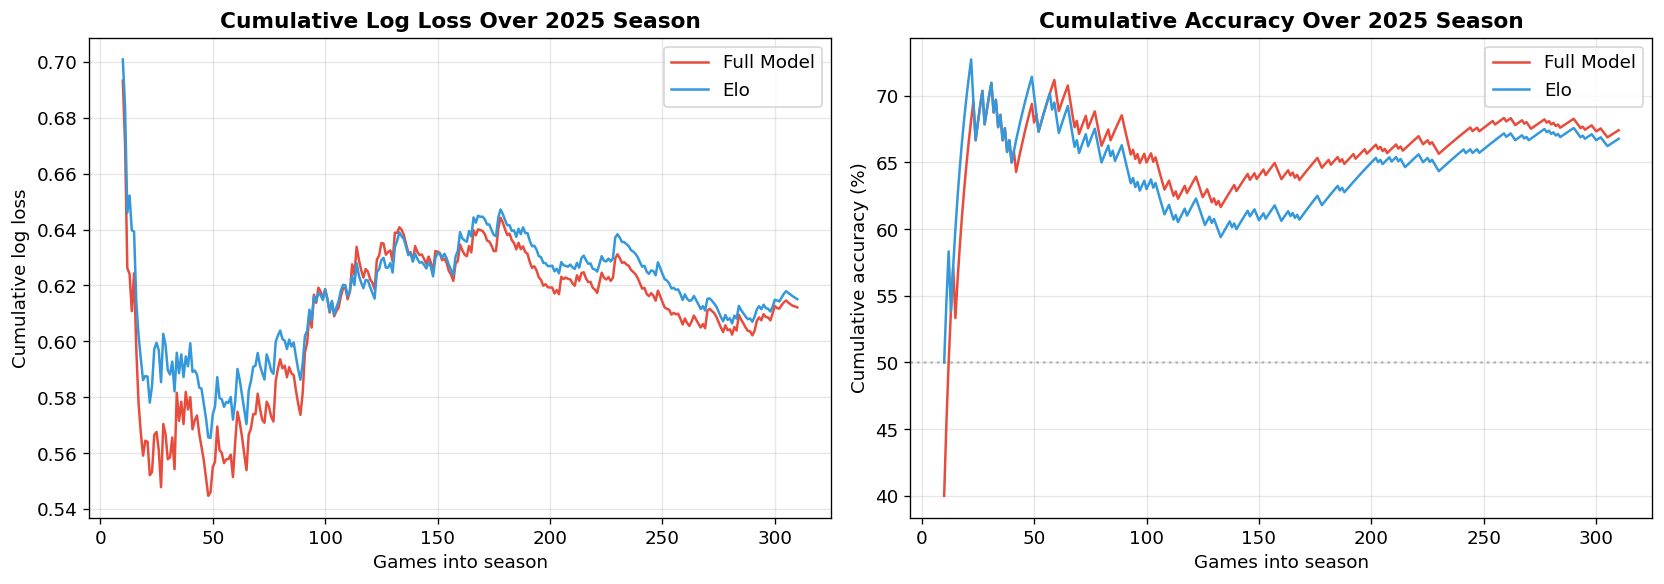

In [8]:
# --- Cumulative log loss over the season ---
sig_sorted = sig.sort_values('game_date').reset_index(drop=True)
cum_ll_fm = []
cum_ll_elo = []
cum_acc_fm = []
cum_acc_elo = []
for i in range(10, len(sig_sorted) + 1):
    y = sig_sorted[LABEL_COL].iloc[:i].values.astype(float)
    pfm = sig_sorted['p_full_model'].iloc[:i].values
    pe = sig_sorted['p_elo'].iloc[:i].values
    cum_ll_fm.append(log_loss(y, pfm))
    cum_ll_elo.append(log_loss(y, pe))
    cum_acc_fm.append(((pfm > 0.5) == y).mean())
    cum_acc_elo.append(((pe > 0.5) == y).mean())

game_nums = list(range(10, len(sig_sorted) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(game_nums, cum_ll_fm, color='#e74c3c', linewidth=1.5, label='Full Model')
ax.plot(game_nums, cum_ll_elo, color='#3498db', linewidth=1.5, label='Elo')
ax.set_xlabel('Games into season')
ax.set_ylabel('Cumulative log loss')
ax.set_title('Cumulative Log Loss Over 2025 Season', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(game_nums, [a * 100 for a in cum_acc_fm], color='#e74c3c', linewidth=1.5, label='Full Model')
ax.plot(game_nums, [a * 100 for a in cum_acc_elo], color='#3498db', linewidth=1.5, label='Elo')
ax.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Games into season')
ax.set_ylabel('Cumulative accuracy (%)')
ax.set_title('Cumulative Accuracy Over 2025 Season', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

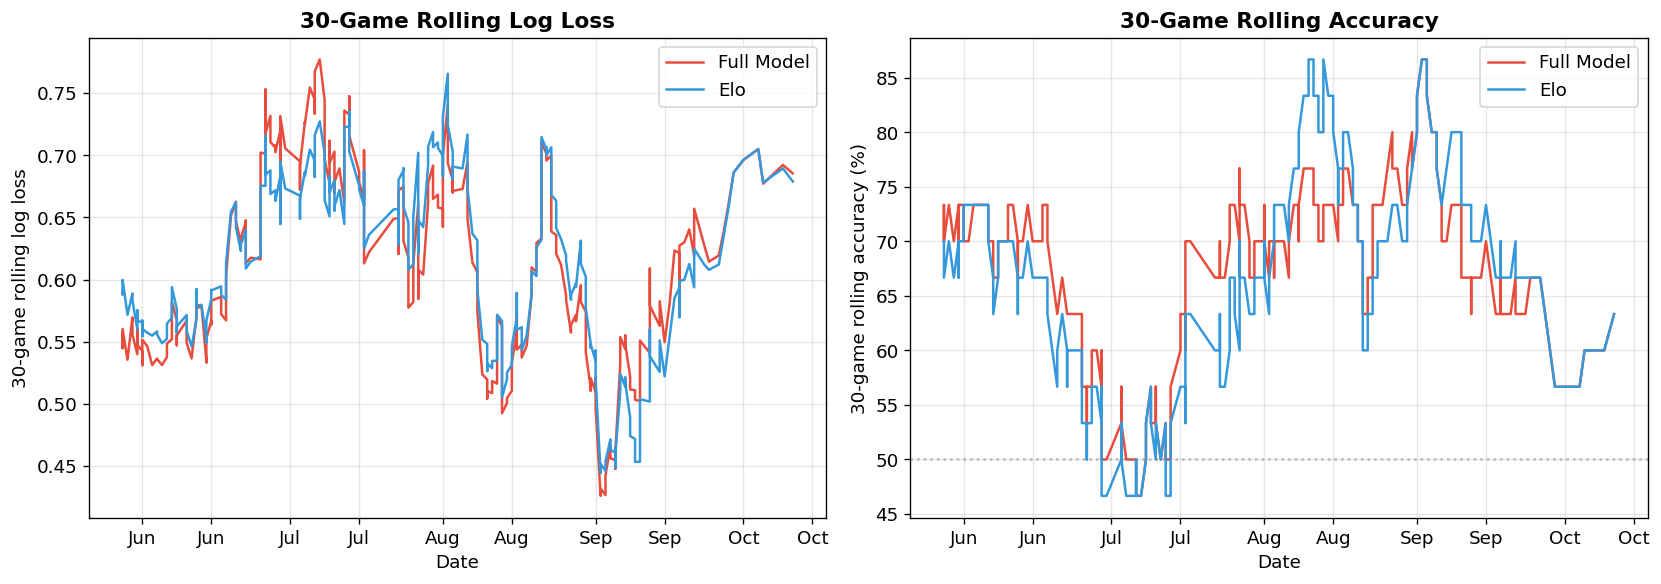

In [9]:
# --- Rolling window log loss (30-game window) ---
WINDOW = 30
roll_ll_fm = []
roll_ll_elo = []
roll_acc_fm = []
roll_acc_elo = []
roll_idx = []

for i in range(WINDOW, len(sig_sorted) + 1):
    y = sig_sorted[LABEL_COL].iloc[i - WINDOW:i].values.astype(float)
    pfm = sig_sorted['p_full_model'].iloc[i - WINDOW:i].values
    pe = sig_sorted['p_elo'].iloc[i - WINDOW:i].values
    roll_ll_fm.append(log_loss(y, pfm))
    roll_ll_elo.append(log_loss(y, pe))
    roll_acc_fm.append(((pfm > 0.5) == y).mean())
    roll_acc_elo.append(((pe > 0.5) == y).mean())
    roll_idx.append(sig_sorted['game_date'].iloc[i - 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(roll_idx, roll_ll_fm, color='#e74c3c', linewidth=1.5, label='Full Model')
ax.plot(roll_idx, roll_ll_elo, color='#3498db', linewidth=1.5, label='Elo')
ax.set_xlabel('Date')
ax.set_ylabel(f'{WINDOW}-game rolling log loss')
ax.set_title(f'{WINDOW}-Game Rolling Log Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

ax = axes[1]
ax.plot(roll_idx, [a * 100 for a in roll_acc_fm], color='#e74c3c', linewidth=1.5, label='Full Model')
ax.plot(roll_idx, [a * 100 for a in roll_acc_elo], color='#3498db', linewidth=1.5, label='Elo')
ax.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel(f'{WINDOW}-game rolling accuracy (%)')
ax.set_title(f'{WINDOW}-Game Rolling Accuracy', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

plt.tight_layout()
plt.show()

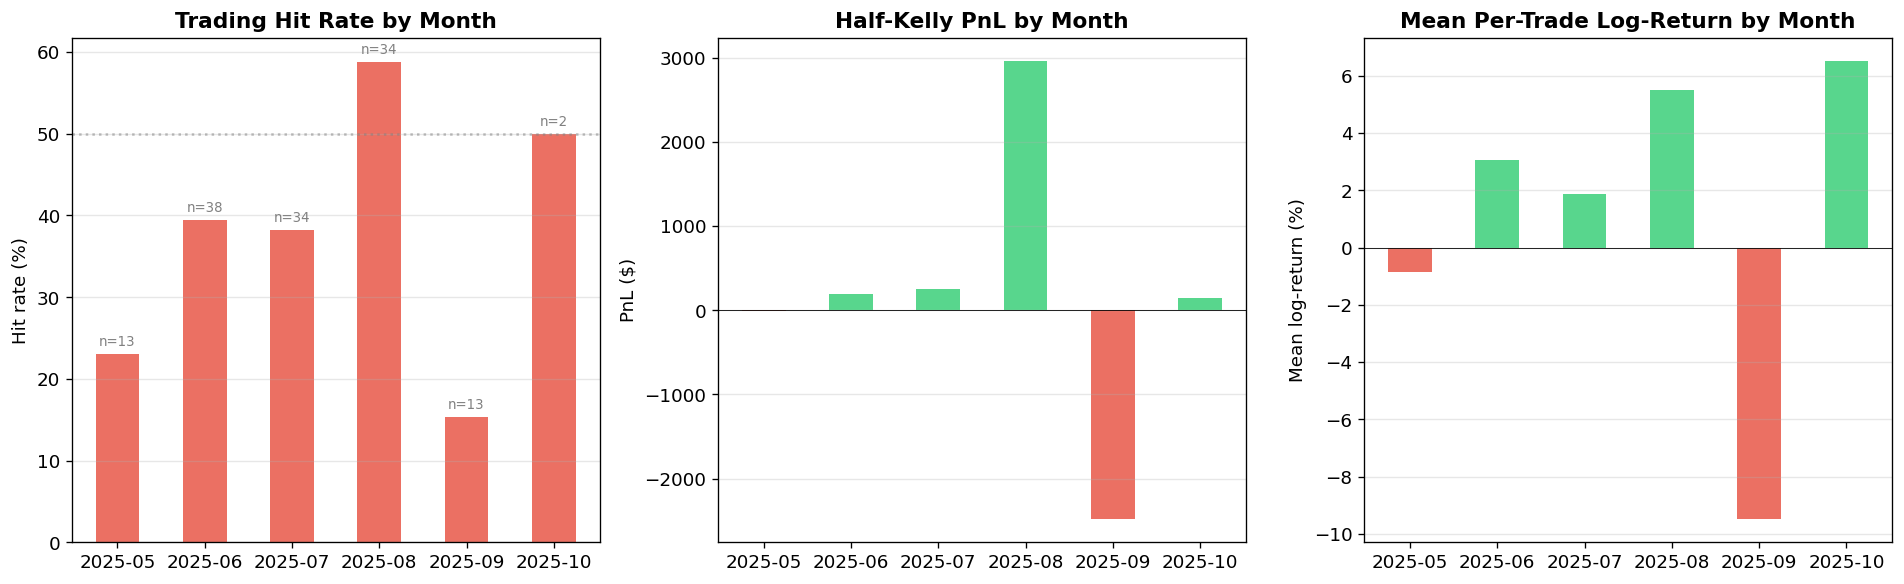

,month_str,n_trades,hit_rate,mean_edge,total_pnl,mean_log_ret
0,2025-05,13,23.1%,0.140,$-10.48,-0.0085
1,2025-06,38,39.5%,0.134,$196.01,0.0305
2,2025-07,34,38.2%,0.122,$251.63,0.0186
3,2025-08,34,58.8%,0.146,$2966.99,0.0552
4,2025-09,13,15.4%,0.130,$-2484.65,-0.0950
5,2025-10,2,50.0%,0.114,$142.30,0.0653


In [10]:
# --- Trading hit rate and PnL by month (half-Kelly trades only) ---
monthly_trades = tdf.groupby('month').agg(
    n_trades=('pnl', 'count'),
    hit_rate=('won', 'mean'),
    total_pnl=('pnl', 'sum'),
    mean_edge=('edge', 'mean'),
    mean_log_ret=('log_ret', 'mean'),
).reset_index()
monthly_trades['month_str'] = monthly_trades['month'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Hit rate by month
ax = axes[0]
bars = ax.bar(monthly_trades['month_str'], monthly_trades['hit_rate'] * 100,
              color='#e74c3c', alpha=0.8, width=0.5)
for bar, n in zip(bars, monthly_trades['n_trades']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={int(n)}', ha='center', fontsize=8, color='gray')
ax.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax.set_ylabel('Hit rate (%)')
ax.set_title('Trading Hit Rate by Month', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# PnL by month
ax = axes[1]
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in monthly_trades['total_pnl']]
ax.bar(monthly_trades['month_str'], monthly_trades['total_pnl'], color=colors, alpha=0.8, width=0.5)
ax.set_ylabel('PnL ($)')
ax.set_title('Half-Kelly PnL by Month', fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Mean log-return by month
ax = axes[2]
colors_lr = ['#2ecc71' if v >= 0 else '#e74c3c' for v in monthly_trades['mean_log_ret']]
ax.bar(monthly_trades['month_str'], monthly_trades['mean_log_ret'] * 100,
       color=colors_lr, alpha=0.8, width=0.5)
ax.set_ylabel('Mean log-return (%)')
ax.set_title('Mean Per-Trade Log-Return by Month', fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

display(monthly_trades[['month_str', 'n_trades', 'hit_rate', 'mean_edge', 'total_pnl', 'mean_log_ret']]
        .style.format({'hit_rate': '{:.1%}', 'mean_edge': '{:.3f}',
                       'total_pnl': '${:.2f}', 'mean_log_ret': '{:.4f}'})
        .set_caption('Monthly trading breakdown (half-Kelly, full model)'))

---
## 2. Entry Price Efficiency

The trading engine scans every 15 minutes within the entry window and enters at the
**first** qualifying snapshot. But within each game's window, there may be cheaper prices
available later. If the minimum available price is often much lower than the actual entry,
a **limit order** at the minimum qualifying price could be a better strategy.

We compare:
- **Actual entry price**: first qualifying snapshot (current strategy)
- **Min entry price**: cheapest qualifying snapshot in the window
- **Max edge price**: snapshot with highest edge in the window

In [22]:
# --- Collect all qualifying snapshots for each traded game ---
all_snaps = collect_all_snapshots('p_full_model', BEST_EDGE_MIN, BEST_NORM_MIN, 'half_life')
snap_df = pd.DataFrame(all_snaps)
snap_df['game_date'] = pd.to_datetime(snap_df['game_id'].map(game_dt_map))

# Per-game: first entry vs best available
first_entry = snap_df.groupby('game_id').first().reset_index()  # first qualifying = our entry
best_price = snap_df.groupby('game_id').agg(
    min_entry_px=('entry_px', 'min'),
    max_edge=('edge', 'max'),
    n_snapshots=('entry_px', 'count'),
).reset_index()

# Also get the entry_px at the max-edge snapshot
max_edge_snap = snap_df.loc[snap_df.groupby('game_id')['edge'].idxmax()][['game_id', 'entry_px']]
max_edge_snap = max_edge_snap.rename(columns={'entry_px': 'max_edge_entry_px'})

price_comp = first_entry[['game_id', 'game_date', 'side', 'entry_px', 'edge', 'p_side', 'home_win']].merge(
    best_price, on='game_id'
).merge(max_edge_snap, on='game_id')
price_comp.rename(columns={'entry_px': 'actual_entry_px', 'edge': 'actual_edge'}, inplace=True)
price_comp['px_improvement'] = price_comp['actual_entry_px'] - price_comp['min_entry_px']
price_comp['edge_improvement'] = price_comp['max_edge'] - price_comp['actual_edge']

# Normalized metrics (relative to entry price)
price_comp['actual_norm_edge'] = price_comp['actual_edge'] / price_comp['actual_entry_px']
price_comp['max_norm_edge'] = price_comp['max_edge'] / price_comp['min_entry_px']
price_comp['norm_edge_improvement'] = price_comp['max_norm_edge'] - price_comp['actual_norm_edge']
price_comp['norm_px_improvement'] = price_comp['px_improvement'] / price_comp['actual_entry_px']

print(f'Traded games: {len(price_comp)}')
print(f'Median qualifying snapshots per game: {price_comp["n_snapshots"].median():.0f}')
print(f'\n--- Entry Price Comparison ---')
print(f'Mean actual entry price:  {price_comp["actual_entry_px"].mean():.4f}')
print(f'Mean min available price: {price_comp["min_entry_px"].mean():.4f}')
print(f'Mean price improvement:   {price_comp["px_improvement"].mean():.4f} ({price_comp["norm_px_improvement"].mean() * 100:.1f}% of entry price)')
print(f'Median price improvement: {price_comp["px_improvement"].median():.4f} ({price_comp["norm_px_improvement"].median() * 100:.1f}% of entry price)')
print(f'\n--- Edge Comparison (absolute) ---')
print(f'Mean actual edge:      {price_comp["actual_edge"].mean():.4f}')
print(f'Mean max edge:         {price_comp["max_edge"].mean():.4f}')
print(f'Mean edge improvement: {price_comp["edge_improvement"].mean():.4f}')
print(f'\n--- Edge Comparison (normalized = edge / entry_price) ---')
print(f'Mean actual norm edge:      {price_comp["actual_norm_edge"].mean():.4f}')
print(f'Mean max norm edge:         {price_comp["max_norm_edge"].mean():.4f}')
print(f'Mean norm edge improvement: {price_comp["norm_edge_improvement"].mean():.4f} ({price_comp["norm_edge_improvement"].mean() / price_comp["actual_norm_edge"].mean() * 100:.1f}% relative)')

Traded games: 134
Median qualifying snapshots per game: 19

--- Entry Price Comparison ---
Mean actual entry price:  0.3157
Mean min available price: 0.2979
Mean price improvement:   0.0178 (6.3% of entry price)
Median price improvement: 0.0100 (4.0% of entry price)

--- Edge Comparison (absolute) ---
Mean actual edge:      0.1338
Mean max edge:         0.1516
Mean edge improvement: 0.0178

--- Edge Comparison (normalized = edge / entry_price) ---
Mean actual norm edge:      0.4940
Mean max norm edge:         0.6112
Mean norm edge improvement: 0.1172 (23.7% relative)


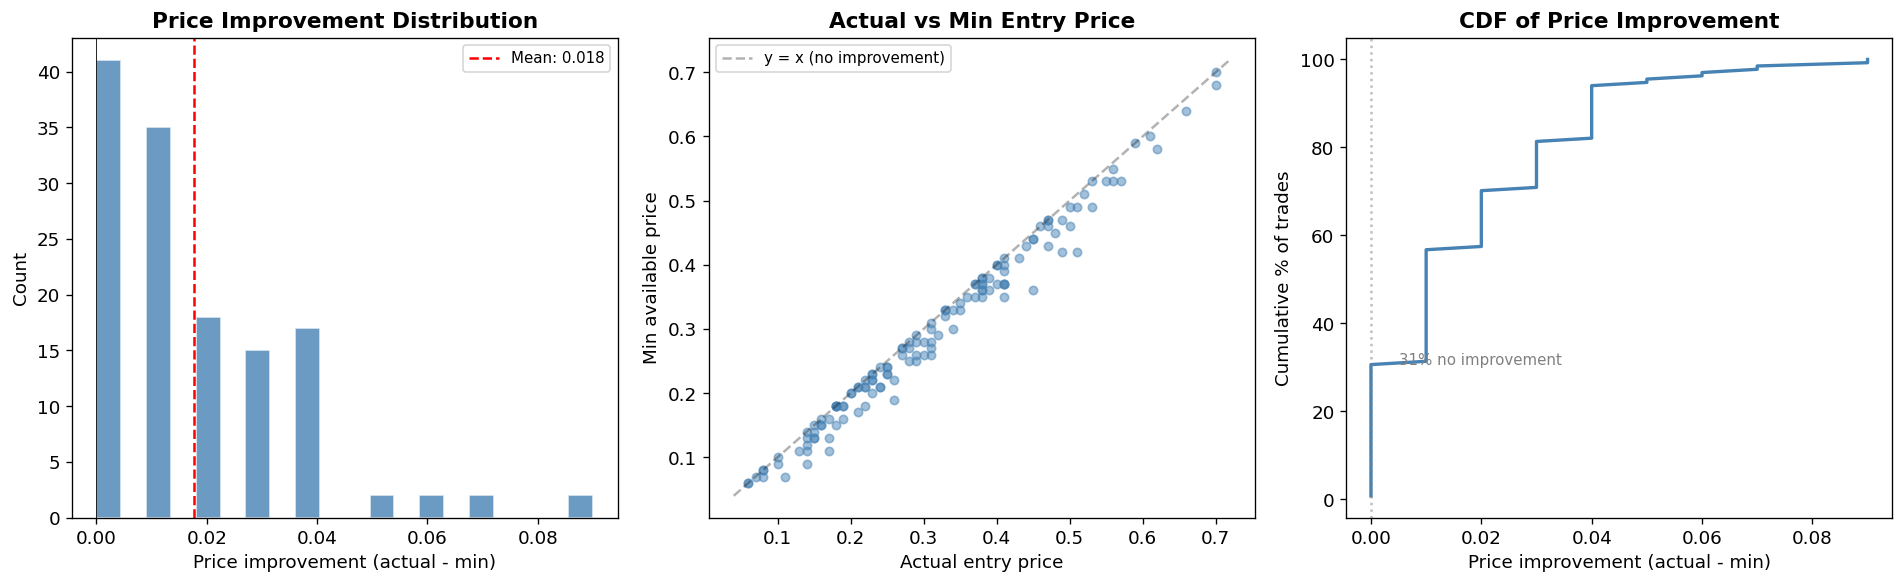


31% of trades had no price improvement (first entry was already the cheapest)
6% of trades had >5¢ improvement available


In [12]:
# --- Visualize price improvement distribution ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Absolute metrics
# Histogram of price improvement
ax = axes[0, 0]
ax.hist(price_comp['px_improvement'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(price_comp['px_improvement'].mean(), color='red', linestyle='--',
           label=f'Mean: {price_comp["px_improvement"].mean():.3f}')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Price improvement (actual - min)')
ax.set_ylabel('Count')
ax.set_title('Absolute Price Improvement', fontweight='bold')
ax.legend(fontsize=9)

# Scatter: actual vs min entry price
ax = axes[0, 1]
ax.scatter(price_comp['actual_entry_px'], price_comp['min_entry_px'],
           alpha=0.5, s=25, color='steelblue')
lims = [price_comp[['actual_entry_px', 'min_entry_px']].min().min() - 0.02,
        price_comp[['actual_entry_px', 'min_entry_px']].max().max() + 0.02]
ax.plot(lims, lims, 'k--', alpha=0.3, label='y = x (no improvement)')
ax.set_xlabel('Actual entry price')
ax.set_ylabel('Min available price')
ax.set_title('Actual vs Min Entry Price', fontweight='bold')
ax.legend(fontsize=9)

# CDF of absolute price improvement
ax = axes[0, 2]
sorted_imp = np.sort(price_comp['px_improvement'])
cdf = np.arange(1, len(sorted_imp) + 1) / len(sorted_imp)
ax.plot(sorted_imp, cdf * 100, color='steelblue', linewidth=2)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
pct_zero = (price_comp['px_improvement'] == 0).mean() * 100
ax.set_xlabel('Price improvement (actual - min)')
ax.set_ylabel('Cumulative % of trades')
ax.set_title('CDF of Absolute Improvement', fontweight='bold')
ax.annotate(f'{pct_zero:.0f}% no improvement', xy=(0.005, pct_zero),
            fontsize=9, color='gray')

# Row 2: Normalized metrics
# Histogram of normalized price improvement
ax = axes[1, 0]
ax.hist(price_comp['norm_px_improvement'] * 100, bins=20, color='#e67e22', alpha=0.8, edgecolor='white')
ax.axvline(price_comp['norm_px_improvement'].mean() * 100, color='red', linestyle='--',
           label=f'Mean: {price_comp["norm_px_improvement"].mean() * 100:.1f}%')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Normalized price improvement (% of entry price)')
ax.set_ylabel('Count')
ax.set_title('Normalized Price Improvement', fontweight='bold')
ax.legend(fontsize=9)

# Scatter: actual norm edge vs max norm edge
ax = axes[1, 1]
ax.scatter(price_comp['actual_norm_edge'], price_comp['max_norm_edge'],
           alpha=0.5, s=25, color='#e67e22')
lims_ne = [min(price_comp['actual_norm_edge'].min(), price_comp['max_norm_edge'].min()) - 0.02,
           max(price_comp['actual_norm_edge'].max(), price_comp['max_norm_edge'].max()) + 0.02]
ax.plot(lims_ne, lims_ne, 'k--', alpha=0.3, label='y = x (no improvement)')
ax.set_xlabel('Actual normalized edge')
ax.set_ylabel('Max normalized edge available')
ax.set_title('Actual vs Max Normalized Edge', fontweight='bold')
ax.legend(fontsize=9)

# CDF of normalized edge improvement
ax = axes[1, 2]
sorted_ne = np.sort(price_comp['norm_edge_improvement'])
cdf_ne = np.arange(1, len(sorted_ne) + 1) / len(sorted_ne)
ax.plot(sorted_ne, cdf_ne * 100, color='#e67e22', linewidth=2)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
pct_zero_ne = (price_comp['norm_edge_improvement'] == 0).mean() * 100
ax.set_xlabel('Normalized edge improvement')
ax.set_ylabel('Cumulative % of trades')
ax.set_title('CDF of Norm Edge Improvement', fontweight='bold')
ax.annotate(f'{pct_zero_ne:.0f}% no improvement', xy=(0.005, pct_zero_ne),
            fontsize=9, color='gray')

plt.tight_layout()
plt.show()

pct_gt_5 = (price_comp['px_improvement'] > 0.05).mean() * 100
pct_norm_gt_10 = (price_comp['norm_px_improvement'] > 0.10).mean() * 100
print(f'{pct_zero:.0f}% of trades had no price improvement (first entry was already the cheapest)')
print(f'{pct_gt_5:.0f}% of trades had >5\u00a2 absolute improvement available')
print(f'{pct_norm_gt_10:.0f}% of trades had >10% normalized improvement available')

In [13]:
# --- Simulate: what if we had entered at the min price instead? ---
# Rebuild entries using min-price snapshots
min_price_snaps = snap_df.loc[snap_df.groupby('game_id')['entry_px'].idxmin()]
min_entries = min_price_snaps.to_dict('records')
trades_min = run_kelly(min_entries, 0.5)
tdf_min = pd.DataFrame(trades_min)

if len(tdf_min) > 0:
    fb_actual = tdf['bankroll'].iloc[-1]
    fb_min = tdf_min['bankroll'].iloc[-1]
    ret_actual = (fb_actual - BANKROLL_INIT) / BANKROLL_INIT
    ret_min = (fb_min - BANKROLL_INIT) / BANKROLL_INIT

    print(f'Strategy comparison (half-Kelly, same games):')
    print(f'  First-qualifying entry: ${fb_actual:.0f} ({ret_actual:.0%} return, {len(tdf)} trades)')
    print(f'  Min-price entry:        ${fb_min:.0f} ({ret_min:.0%} return, {len(tdf_min)} trades)')
    print(f'  Improvement:            {(ret_min - ret_actual):.0%} return')
    print(f'\nNote: min-price entry is not achievable in practice — it requires')
    print(f'perfect foresight about which snapshot will be cheapest.')
    print(f'However, it gives an upper bound on what limit-order improvement could achieve.')
else:
    print('No trades produced with min-price entries.')

Strategy comparison (half-Kelly, same games):
  First-qualifying entry: $1162 (1062% return, 134 trades)
  Min-price entry:        $2581 (2481% return, 134 trades)
  Improvement:            1420% return

Note: min-price entry is not achievable in practice — it requires
perfect foresight about which snapshot will be cheapest.
However, it gives an upper bound on what limit-order improvement could achieve.


In [23]:
# --- Simulate: what if we entered at the WORST qualifying price? ---
# This is the "lazy entry" counterfactual: enter at the most expensive snapshot
# in the window that still meets our edge/norm thresholds.
max_price_snaps = snap_df.loc[snap_df.groupby('game_id')['entry_px'].idxmax()]
max_entries = max_price_snaps.to_dict('records')
trades_max = run_kelly(max_entries, 0.5)
tdf_max = pd.DataFrame(trades_max)

fb_actual = tdf['bankroll'].iloc[-1]
ret_actual = (fb_actual - BANKROLL_INIT) / BANKROLL_INIT

results = [('First-qualifying (current)', tdf, fb_actual, ret_actual)]

if len(tdf_min) > 0:
    fb_min = tdf_min['bankroll'].iloc[-1]
    ret_min = (fb_min - BANKROLL_INIT) / BANKROLL_INIT
    results.append(('Best price (foresight)', tdf_min, fb_min, ret_min))

if len(tdf_max) > 0:
    fb_max = tdf_max['bankroll'].iloc[-1]
    ret_max = (fb_max - BANKROLL_INIT) / BANKROLL_INIT
    results.append(('Worst price (lazy entry)', tdf_max, fb_max, ret_max))

print('Strategy comparison (half-Kelly):')
print(f'{"Strategy":<30} {"Trades":>6} {"Hit Rate":>9} {"Final $":>10} {"Return":>10} {"Mean Edge":>10}')
print('-' * 78)
for label, df, fb, ret in results:
    print(f'{label:<30} {len(df):>6} {df["won"].mean():>8.1%} {fb:>9.0f} {ret:>9.0%} {df["edge"].mean():>9.4f}')

Strategy comparison (half-Kelly):
Strategy                       Trades  Hit Rate    Final $     Return  Mean Edge
------------------------------------------------------------------------------
First-qualifying (current)        134    40.3%      1162     1062%    0.1338
Best price (foresight)            134    40.3%      2581     2481%    0.1516
Worst price (lazy entry)          134    40.3%       603      503%    0.1267


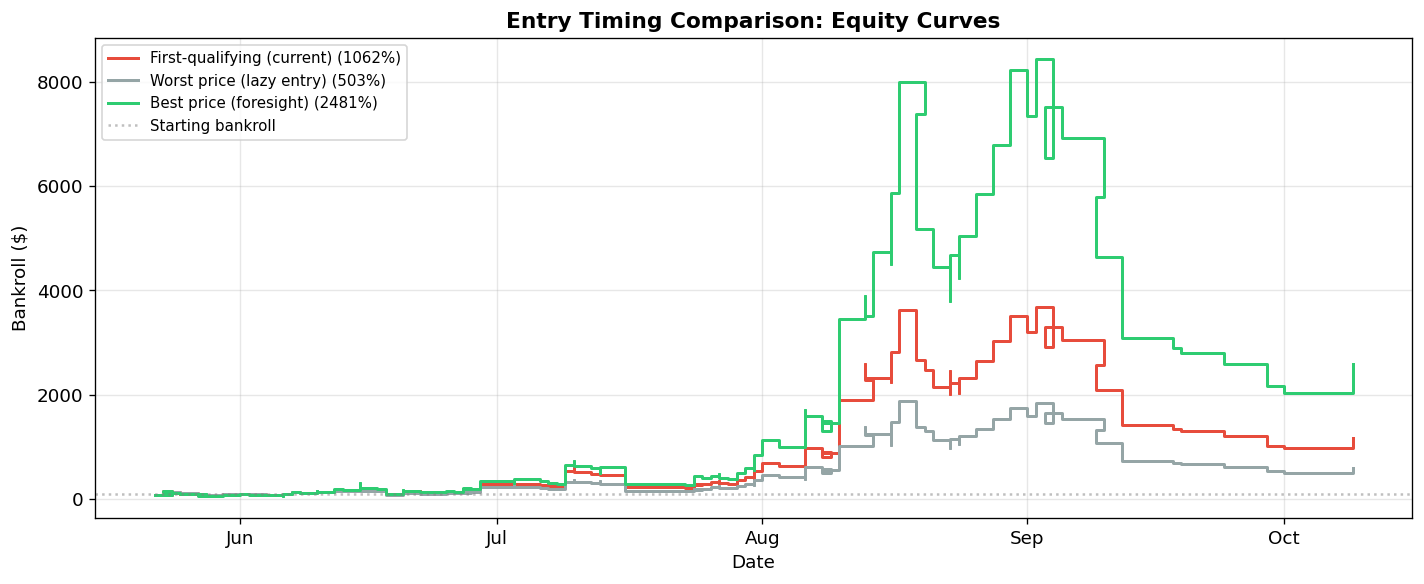

In [24]:
# --- Equity curve comparison: current vs worst-price vs best-price ---
fig, ax = plt.subplots(figsize=(12, 5))

strategies = [
    ('First-qualifying (current)', tdf, '#e74c3c'),
    ('Worst price (lazy entry)', tdf_max, '#95a5a6'),
]
if len(tdf_min) > 0:
    strategies.append(('Best price (foresight)', tdf_min, '#2ecc71'))

for label, df, color in strategies:
    df_plot = df.copy()
    df_plot['game_date'] = pd.to_datetime(df_plot['game_id'].map(game_dt_map))
    ret = (df['bankroll'].iloc[-1] / BANKROLL_INIT - 1)
    ax.step(df_plot['game_date'], df_plot['bankroll'], where='post',
            color=color, linewidth=1.8, label=f'{label} ({ret:.0%})')

ax.axhline(BANKROLL_INIT, color='gray', linestyle=':', alpha=0.5, label='Starting bankroll')
ax.set_xlabel('Date')
ax.set_ylabel('Bankroll ($)')
ax.set_title('Entry Timing Comparison: Equity Curves', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

plt.tight_layout()
plt.show()

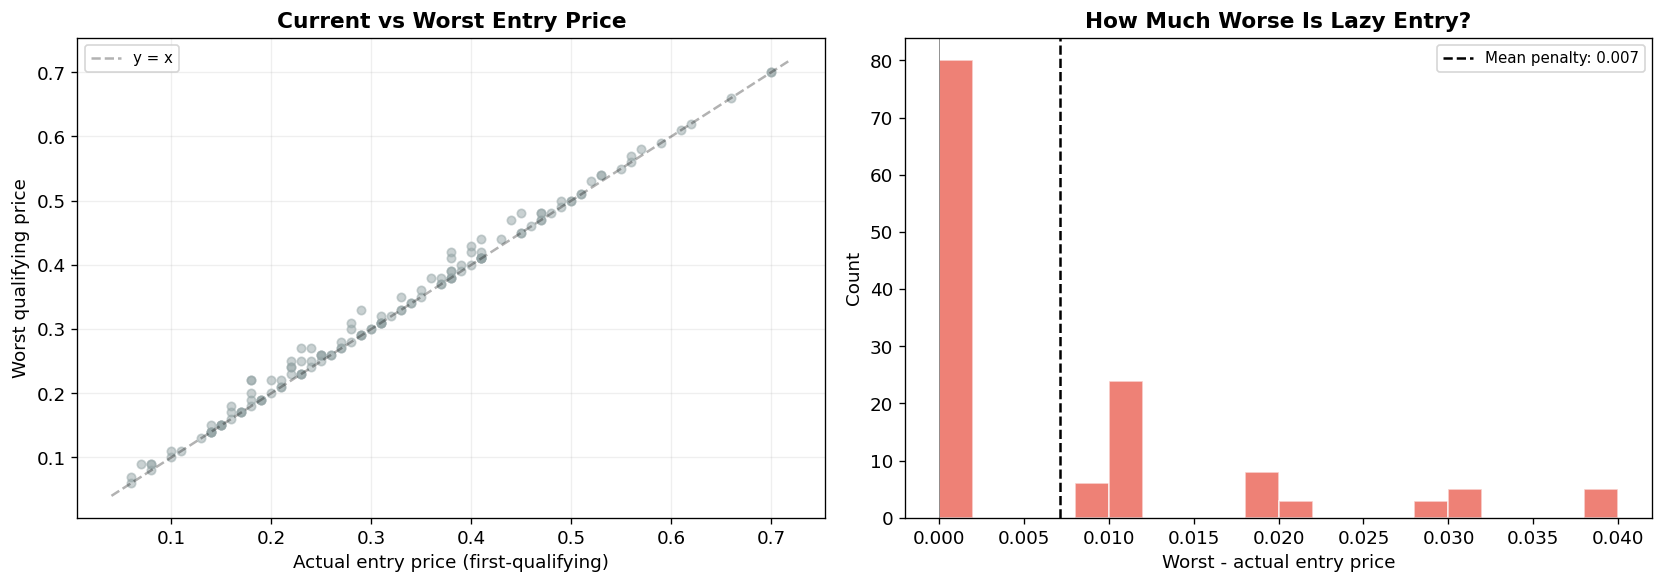

60% of games had only one qualifying snapshot (no timing difference)
Mean worst-price penalty: 0.0072 (2.3% of entry price)
Max worst-price penalty:  0.0400


In [25]:
# --- Per-game entry price comparison: current vs worst vs best ---
price_comp['max_entry_px'] = snap_df.groupby('game_id')['entry_px'].max().reindex(price_comp['game_id']).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs max (worst) entry price
ax = axes[0]
ax.scatter(price_comp['actual_entry_px'], price_comp['max_entry_px'],
           alpha=0.5, s=25, color='#95a5a6')
lims = [min(price_comp[['actual_entry_px', 'max_entry_px']].min().min(),
            price_comp[['actual_entry_px', 'max_entry_px']].min().min()) - 0.02,
        max(price_comp[['actual_entry_px', 'max_entry_px']].max().max(),
            price_comp[['actual_entry_px', 'max_entry_px']].max().max()) + 0.02]
ax.plot(lims, lims, 'k--', alpha=0.3, label='y = x')
ax.set_xlabel('Actual entry price (first-qualifying)')
ax.set_ylabel('Worst qualifying price')
ax.set_title('Current vs Worst Entry Price', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Distribution of worst-price penalty
ax = axes[1]
penalty = price_comp['max_entry_px'] - price_comp['actual_entry_px']
ax.hist(penalty, bins=20, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(penalty.mean(), color='black', linestyle='--',
           label=f'Mean penalty: {penalty.mean():.3f}')
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Worst - actual entry price')
ax.set_ylabel('Count')
ax.set_title('How Much Worse Is Lazy Entry?', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

pct_same = (penalty == 0).mean() * 100
print(f'{pct_same:.0f}% of games had only one qualifying snapshot (no timing difference)')
print(f'Mean worst-price penalty: {penalty.mean():.4f} ({penalty.mean() / price_comp["actual_entry_px"].mean() * 100:.1f}% of entry price)')
print(f'Max worst-price penalty:  {penalty.max():.4f}')

---
## 3. What Drives Returns?

Decompose which trade characteristics are associated with the highest returns:
- Model edge at entry
- Entry price (market implied probability)
- Model probability
- Kelly fraction

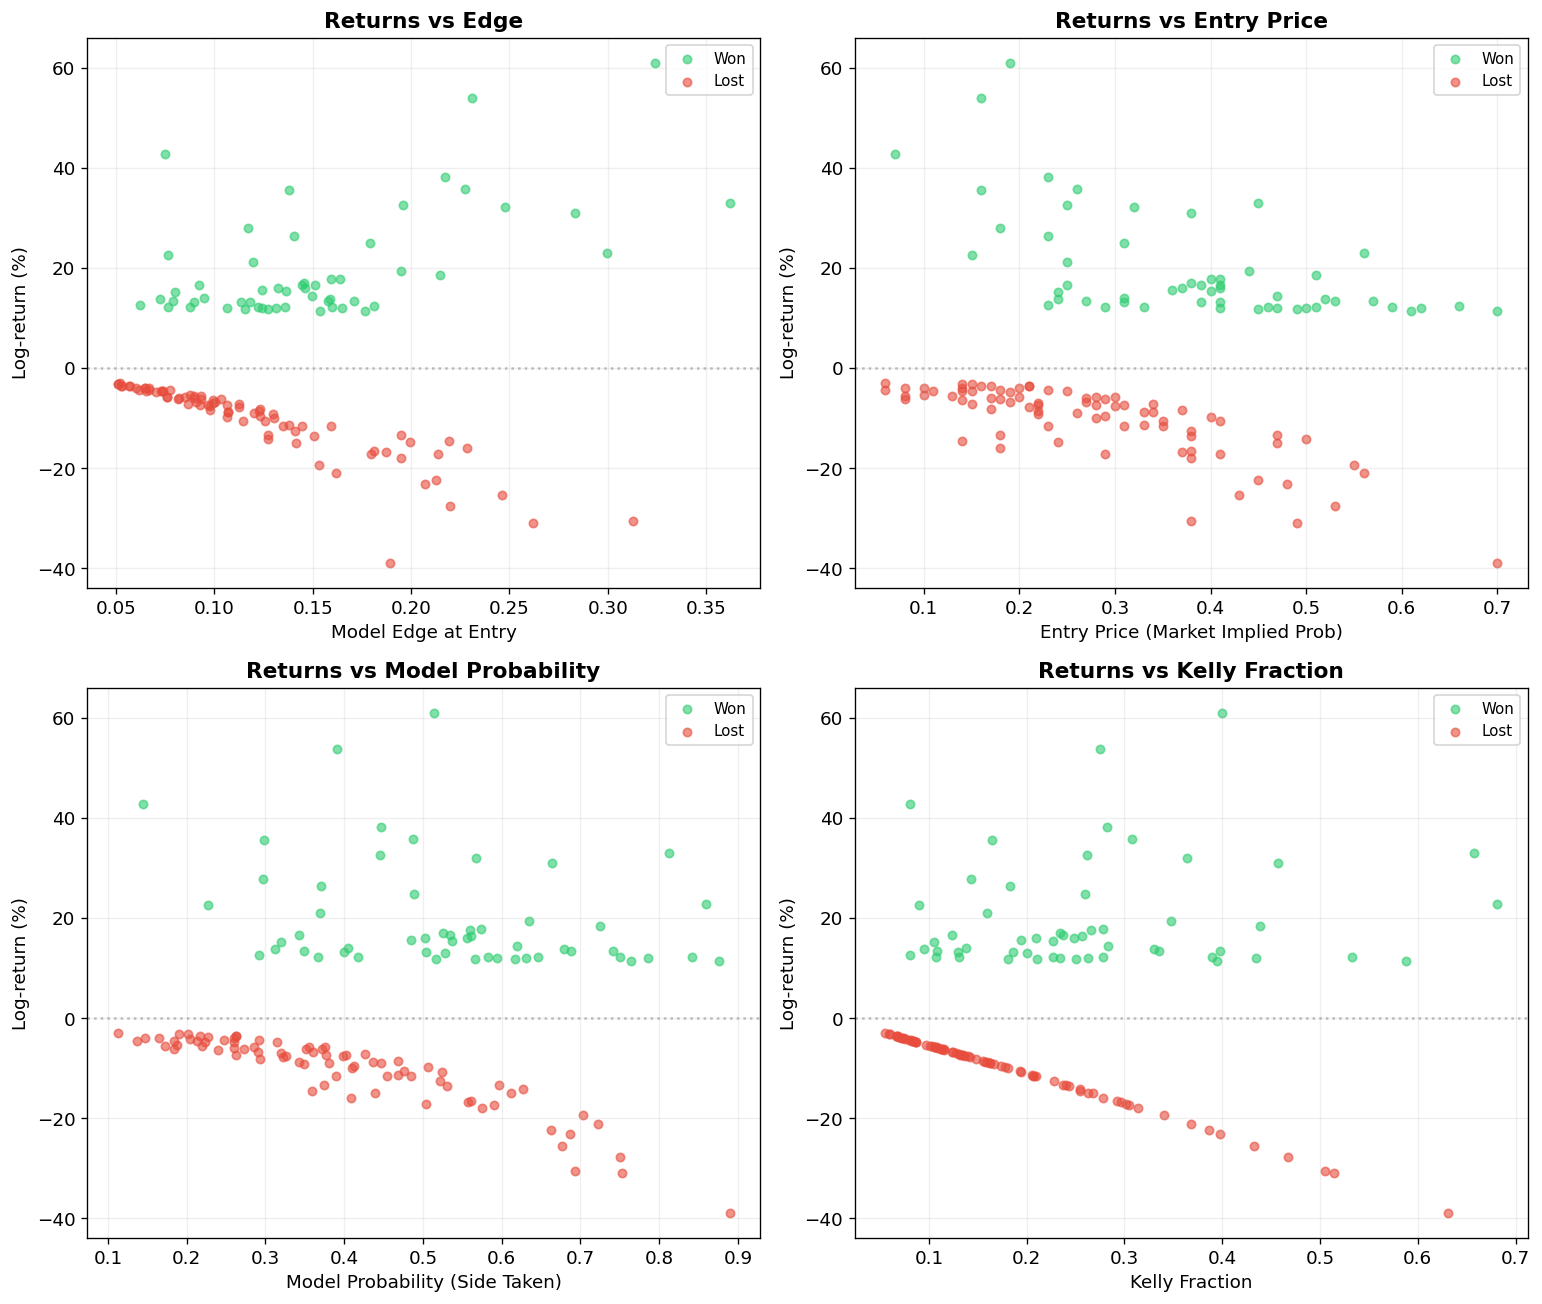

In [14]:
# --- Return drivers: scatter plots ---
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

won_mask = tdf['won'] == 1
lost_mask = ~won_mask

plot_configs = [
    ('edge', 'Model Edge at Entry', axes[0, 0]),
    ('entry_px', 'Entry Price (Market Implied Prob)', axes[0, 1]),
    ('p_side', 'Model Probability (Side Taken)', axes[1, 0]),
    ('kelly_f', 'Kelly Fraction', axes[1, 1]),
]

for col, xlabel, ax in plot_configs:
    ax.scatter(tdf.loc[won_mask, col], tdf.loc[won_mask, 'log_ret'] * 100,
              c='#2ecc71', alpha=0.6, s=25, label='Won')
    ax.scatter(tdf.loc[lost_mask, col], tdf.loc[lost_mask, 'log_ret'] * 100,
              c='#e74c3c', alpha=0.6, s=25, label='Lost')
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Log-return (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

axes[0, 0].set_title('Returns vs Edge', fontweight='bold')
axes[0, 1].set_title('Returns vs Entry Price', fontweight='bold')
axes[1, 0].set_title('Returns vs Model Probability', fontweight='bold')
axes[1, 1].set_title('Returns vs Kelly Fraction', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# --- Return drivers: bucketed analysis ---
def bucket_analysis(df, col, bins, labels):
    df = df.copy()
    df['bucket'] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
    return df.groupby('bucket', observed=True).agg(
        n=('pnl', 'count'),
        hit_rate=('won', 'mean'),
        mean_pnl=('pnl', 'mean'),
        total_pnl=('pnl', 'sum'),
        mean_log_ret=('log_ret', 'mean'),
        mean_wager=('wager', 'mean'),
        mean_edge=('edge', 'mean'),
    ).reset_index()

# Edge buckets
edge_buckets = bucket_analysis(tdf, 'edge',
    bins=[0, 0.10, 0.15, 0.20, 0.30, 1.0],
    labels=['5-10%', '10-15%', '15-20%', '20-30%', '30%+'])

# Entry price buckets
px_buckets = bucket_analysis(tdf, 'entry_px',
    bins=[0, 0.30, 0.40, 0.50, 0.60, 1.0],
    labels=['<30¢', '30-40¢', '40-50¢', '50-60¢', '>60¢'])

# Model probability buckets
pmodel_buckets = bucket_analysis(tdf, 'p_side',
    bins=[0.5, 0.60, 0.65, 0.70, 0.80, 1.0],
    labels=['50-60%', '60-65%', '65-70%', '70-80%', '80%+'])

print('=== Returns by Edge Bucket ===')
display(edge_buckets.style.format({
    'hit_rate': '{:.1%}', 'mean_pnl': '${:.2f}', 'total_pnl': '${:.2f}',
    'mean_log_ret': '{:.4f}', 'mean_wager': '${:.2f}', 'mean_edge': '{:.3f}',
}))

print('\n=== Returns by Entry Price Bucket ===')
display(px_buckets.style.format({
    'hit_rate': '{:.1%}', 'mean_pnl': '${:.2f}', 'total_pnl': '${:.2f}',
    'mean_log_ret': '{:.4f}', 'mean_wager': '${:.2f}', 'mean_edge': '{:.3f}',
}))

print('\n=== Returns by Model Probability Bucket ===')
display(pmodel_buckets.style.format({
    'hit_rate': '{:.1%}', 'mean_pnl': '${:.2f}', 'total_pnl': '${:.2f}',
    'mean_log_ret': '{:.4f}', 'mean_wager': '${:.2f}', 'mean_edge': '{:.3f}',
}))

=== Returns by Edge Bucket ===


,bucket,n,hit_rate,mean_pnl,total_pnl,mean_log_ret,mean_wager,mean_edge
0,5-10%,48,22.9%,$-4.47,$-214.79,-0.0008,$29.11,0.077
1,10-15%,43,46.5%,$36.95,$1589.00,0.0241,$102.27,0.125
2,15-20%,25,56.0%,$6.99,$174.76,0.0110,$186.74,0.173
3,20-30%,15,46.7%,$-54.21,$-813.17,0.0366,$262.07,0.235
4,30%+,3,66.7%,$108.66,$325.99,0.2111,$95.53,0.333



=== Returns by Entry Price Bucket ===


,bucket,n,hit_rate,mean_pnl,total_pnl,mean_log_ret,mean_wager,mean_edge
0,<30¢,66,25.8%,$-18.74,$-1237.04,0.0224,$45.34,0.109
1,30-40¢,31,41.9%,$39.37,$1220.56,0.0071,$57.06,0.143
2,40-50¢,22,59.1%,$20.62,$453.66,0.0133,$221.76,0.165
3,50-60¢,10,70.0%,$76.32,$763.21,0.0383,$330.40,0.183
4,>60¢,5,80.0%,$-27.72,$-138.61,0.0163,$347.42,0.173



=== Returns by Model Probability Bucket ===


,bucket,n,hit_rate,mean_pnl,total_pnl,mean_log_ret,mean_wager,mean_edge
0,50-60%,26,61.5%,$51.56,$1340.66,0.0594,$114.21,0.156
1,60-65%,7,71.4%,$154.59,$1082.16,0.0579,$238.50,0.144
2,65-70%,7,42.9%,$-13.76,$-96.35,-0.0621,$219.77,0.225
3,70-80%,9,55.6%,$-133.92,$-1205.27,-0.0349,$338.31,0.185
4,80%+,5,80.0%,$128.03,$640.14,0.0811,$520.01,0.242


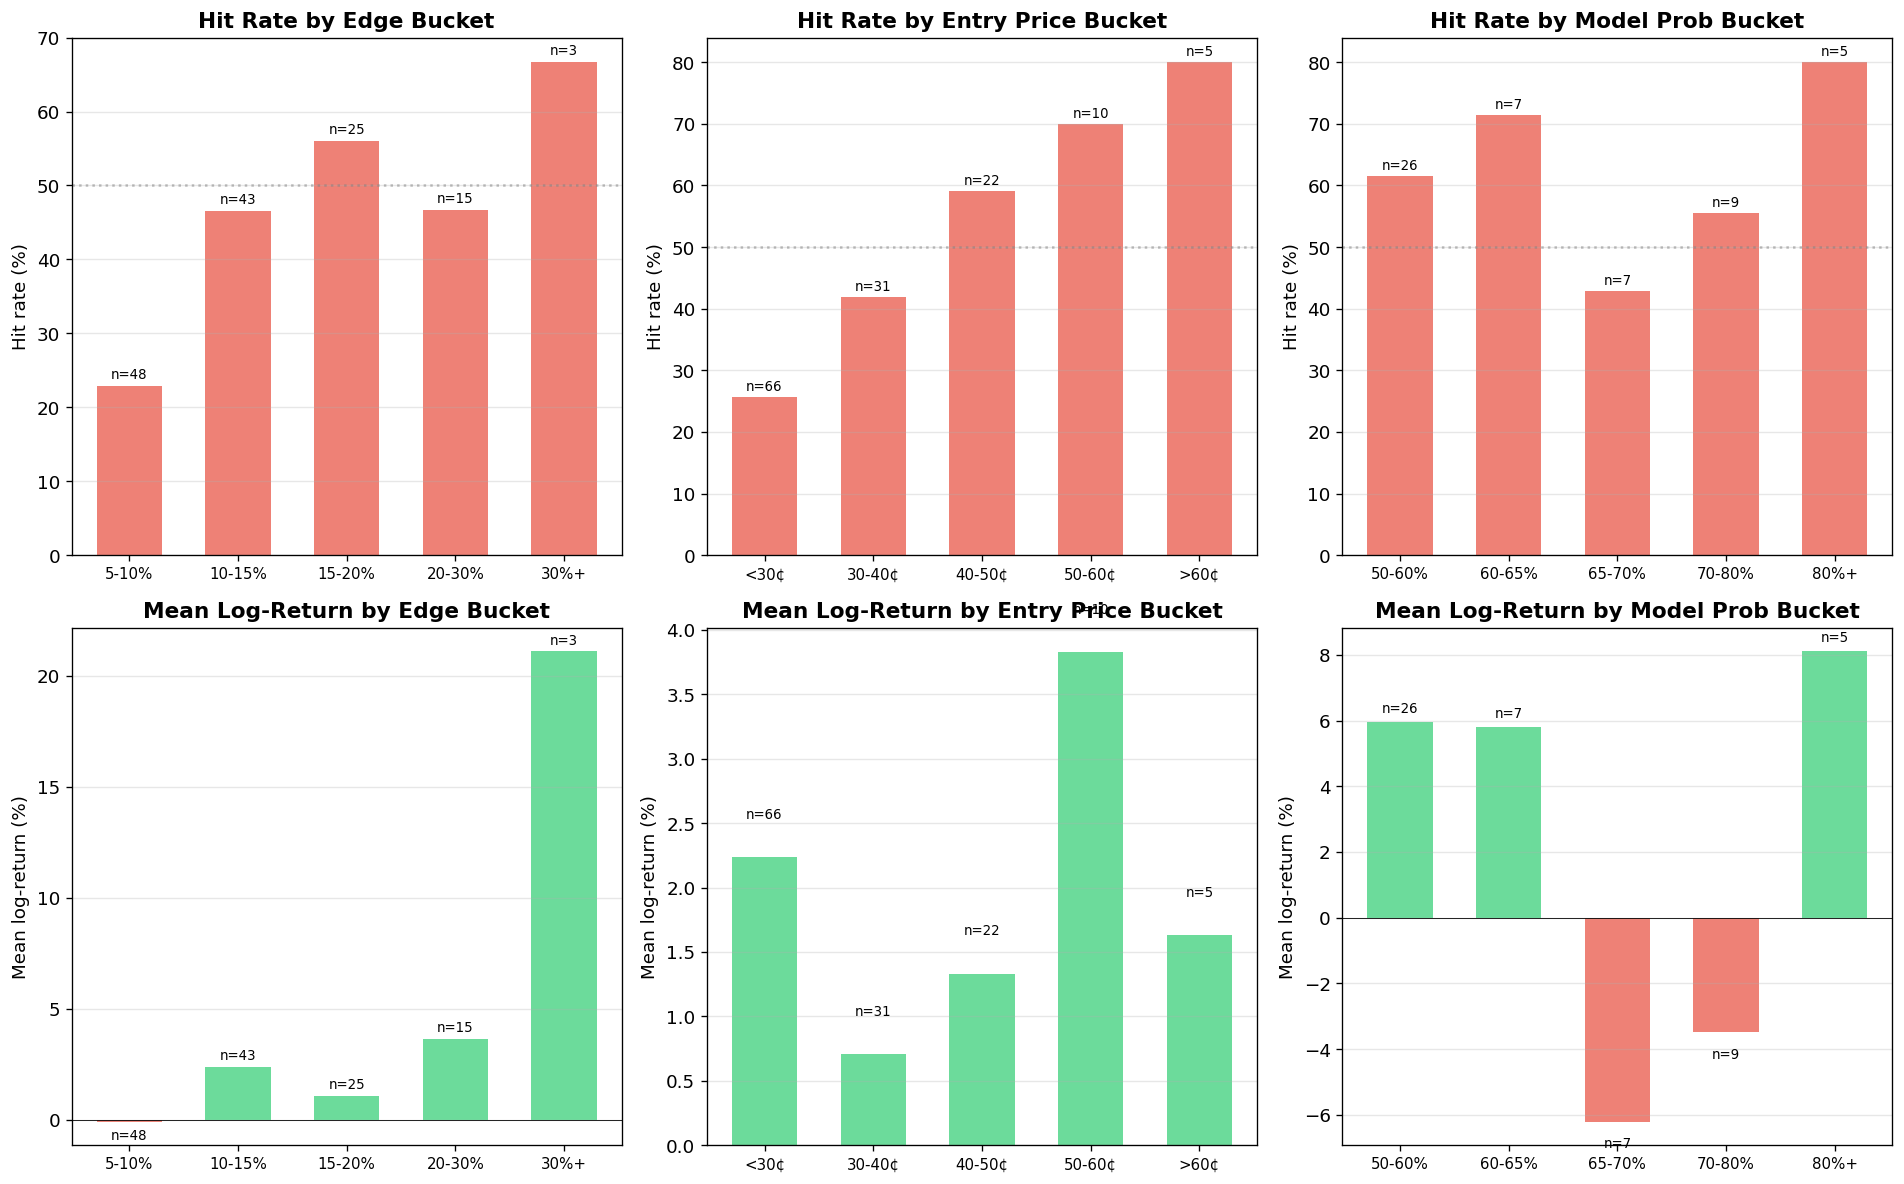

In [21]:
# --- Bucketed bar charts: hit rate and mean log-return by edge, price, and model prob ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

bucket_sets = [
    (edge_buckets, 'Edge Bucket', 'bucket'),
    (px_buckets, 'Entry Price Bucket', 'bucket'),
    (pmodel_buckets, 'Model Prob Bucket', 'bucket'),
]

for j, (bdf, title, xcol) in enumerate(bucket_sets):
    # Hit rate
    ax = axes[0, j]
    x = range(len(bdf))
    bars = ax.bar(x, bdf['hit_rate'] * 100, color='#e74c3c', alpha=0.7, width=0.6)
    for xi, bar, n in zip(x, bars, bdf['n']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'n={int(n)}', ha='center', fontsize=8)
    ax.axhline(50, color='gray', linestyle=':', alpha=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(bdf[xcol], fontsize=9)
    ax.set_ylabel('Hit rate (%)')
    ax.set_title(f'Hit Rate by {title}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Mean log-return
    ax = axes[1, j]
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in bdf['mean_log_ret']]
    bars = ax.bar(x, bdf['mean_log_ret'] * 100, color=colors, alpha=0.7, width=0.6)
    for xi, bar, n in zip(x, bars, bdf['n']):
        y = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, y + (0.3 if y >= 0 else -0.8),
                f'n={int(n)}', ha='center', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(bdf[xcol], fontsize=9)
    ax.set_ylabel('Mean log-return (%)')
    ax.set_title(f'Mean Log-Return by {title}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# --- Top / bottom trades breakdown ---
tdf_sorted = tdf.sort_values('log_ret', ascending=False).reset_index(drop=True)

show_cols = ['game_date', 'side', 'entry_px', 'p_side', 'edge', 'kelly_f',
             'wager', 'pnl', 'log_ret', 'won']

print('=== Top 10 trades by log-return ===')
display(tdf_sorted.head(10)[show_cols].style.format({
    'entry_px': '{:.2f}', 'p_side': '{:.3f}', 'edge': '{:.3f}',
    'kelly_f': '{:.3f}', 'wager': '${:.2f}', 'pnl': '${:.2f}',
    'log_ret': '{:.4f}',
}))

print('\n=== Bottom 10 trades by log-return ===')
display(tdf_sorted.tail(10)[show_cols].style.format({
    'entry_px': '{:.2f}', 'p_side': '{:.3f}', 'edge': '{:.3f}',
    'kelly_f': '{:.3f}', 'wager': '${:.2f}', 'pnl': '${:.2f}',
    'log_ret': '{:.4f}',
}))

=== Top 10 trades by log-return ===


,game_date,side,entry_px,p_side,edge,kelly_f,wager,pnl,log_ret,won
0,2025-05-24 00:00:00,NO,0.19,0.514,0.324,0.400,$15.92,$66.96,0.6101,1
1,2025-06-20 00:00:00,YES,0.16,0.391,0.231,0.275,$13.01,$67.51,0.5384,1
2,2025-07-09 00:00:00,YES,0.07,0.145,0.075,0.081,$9.51,$125.75,0.4278,1
3,2025-07-09 00:00:00,NO,0.23,0.447,0.217,0.282,$50.96,$167.85,0.3816,1
4,2025-06-15 00:00:00,YES,0.26,0.488,0.228,0.308,$26.62,$74.37,0.3575,1
5,2025-06-07 00:00:00,YES,0.16,0.298,0.138,0.164,$7.72,$40.07,0.3554,1
6,2025-08-06 00:00:00,NO,0.45,0.812,0.362,0.658,$243.11,$287.78,0.3289,1
7,2025-06-29 00:00:00,NO,0.25,0.446,0.196,0.261,$23.86,$70.33,0.3259,1
8,2025-06-10 00:00:00,NO,0.32,0.568,0.248,0.364,$20.16,$41.89,0.3208,1
9,2025-08-10 00:00:00,NO,0.38,0.663,0.283,0.457,$233.20,$370.35,0.3096,1



=== Bottom 10 trades by log-return ===


,game_date,side,entry_px,p_side,edge,kelly_f,wager,pnl,log_ret,won
124,2025-06-20 00:00:00,YES,0.38,0.575,0.195,0.314,$25.48,$-26.59,-0.1791,0
125,2025-08-16 00:00:00,YES,0.55,0.703,0.153,0.340,$463.17,$-477.76,-0.1928,0
126,2025-09-09 00:00:00,NO,0.56,0.722,0.162,0.368,$473.94,$-488.54,-0.2105,0
127,2025-06-15 00:00:00,YES,0.45,0.663,0.213,0.386,$47.81,$-49.66,-0.2240,0
128,2025-09-04 00:00:00,NO,0.48,0.687,0.207,0.398,$732.27,$-758.93,-0.2310,0
129,2025-06-18 00:00:00,NO,0.43,0.676,0.246,0.432,$36.84,$-38.31,-0.2547,0
130,2025-07-16 00:00:00,NO,0.53,0.750,0.220,0.468,$104.84,$-108.29,-0.2765,0
131,2025-05-27 00:00:00,YES,0.38,0.693,0.313,0.505,$27.55,$-28.75,-0.3056,0
132,2025-08-19 00:00:00,NO,0.49,0.752,0.262,0.514,$932.37,$-965.66,-0.3095,0
133,2025-09-12 00:00:00,NO,0.70,0.889,0.189,0.631,$657.51,$-671.32,-0.3886,0


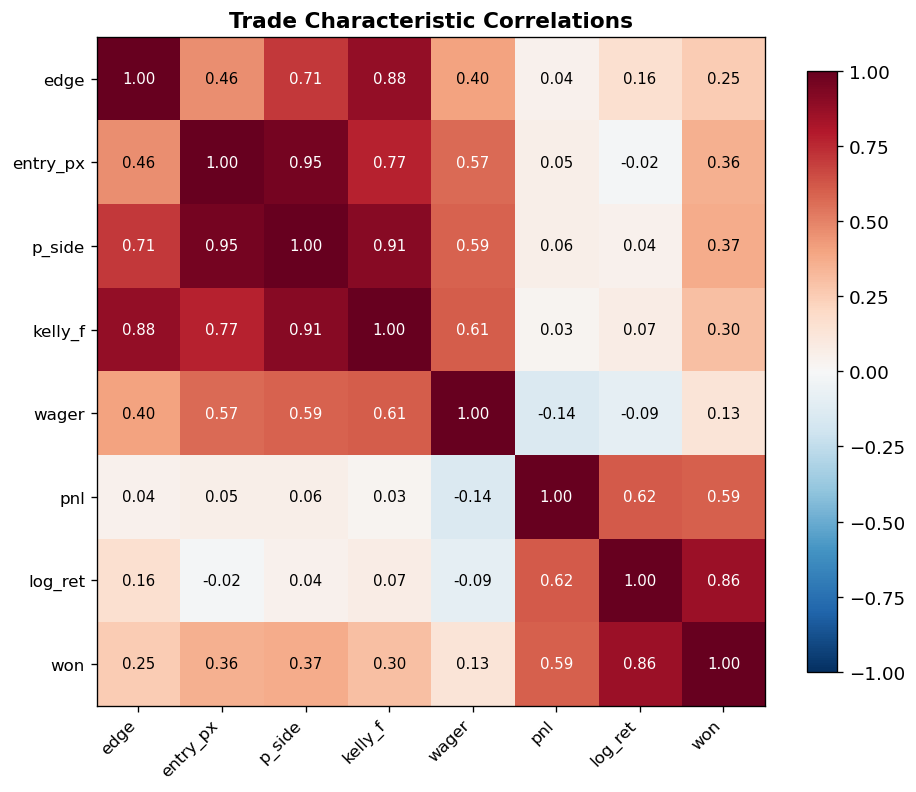

In [18]:
# --- Correlation matrix of trade characteristics ---
corr_cols = ['edge', 'entry_px', 'p_side', 'kelly_f', 'wager', 'pnl', 'log_ret', 'won']
corr = tdf[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr_cols, fontsize=10)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(corr.values[i, j]) > 0.5 else 'black')

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Trade Characteristic Correlations', fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# --- Summary statistics ---
print('═══ Return Investigation Summary ═══')
print(f'\nBest half-Kelly config: edge >= {BEST_EDGE_MIN}, norm >= {BEST_NORM_MIN}')
print(f'Total trades: {len(tdf)}, Hit rate: {tdf["won"].mean():.1%}')
print(f'Final bankroll: ${tdf["bankroll"].iloc[-1]:.0f} ({(tdf["bankroll"].iloc[-1] / BANKROLL_INIT - 1):.0%} return)')
print(f'\n--- Seasonal Pattern ---')
first_half = tdf[tdf['game_date'] < tdf['game_date'].median()]
second_half = tdf[tdf['game_date'] >= tdf['game_date'].median()]
print(f'First half:  {len(first_half)} trades, {first_half["won"].mean():.1%} hit rate, '
      f'mean log-ret {first_half["log_ret"].mean():.4f}')
print(f'Second half: {len(second_half)} trades, {second_half["won"].mean():.1%} hit rate, '
      f'mean log-ret {second_half["log_ret"].mean():.4f}')
print(f'\n--- Entry Price Efficiency ---')
print(f'Mean actual entry:       {tdf["entry_px"].mean():.3f}')
print(f'Mean min available:      {price_comp["min_entry_px"].mean():.3f}')
print(f'Mean abs improvement:    {price_comp["px_improvement"].mean():.3f}')
print(f'Mean norm improvement:   {price_comp["norm_px_improvement"].mean() * 100:.1f}% of entry price')
print(f'Mean actual norm edge:   {price_comp["actual_norm_edge"].mean():.3f}')
print(f'Mean max norm edge:      {price_comp["max_norm_edge"].mean():.3f}')
print(f'Mean norm edge gain:     {price_comp["norm_edge_improvement"].mean():.3f}')
print(f'\n--- Return Drivers ---')
print(f'Correlation(edge, log_ret):     {tdf["edge"].corr(tdf["log_ret"]):.3f}')
print(f'Correlation(entry_px, log_ret): {tdf["entry_px"].corr(tdf["log_ret"]):.3f}')
print(f'Correlation(kelly_f, log_ret):  {tdf["kelly_f"].corr(tdf["log_ret"]):.3f}')
print(f'Correlation(p_side, log_ret):   {tdf["p_side"].corr(tdf["log_ret"]):.3f}')

═══ Return Investigation Summary ═══

Best half-Kelly config: edge >= 0.05, norm >= 0.25
Total trades: 134, Hit rate: 40.3%
Final bankroll: $1162 (1062% return)

--- Seasonal Pattern ---
First half:  64 trades, 35.9% hit rate, mean log-ret 0.0241
Second half: 70 trades, 44.3% hit rate, mean log-ret 0.0130

--- Entry Price Efficiency ---
Mean actual entry:  0.316
Mean min available: 0.298
Mean improvement:   0.018 (5.6%)

--- Return Drivers ---
Correlation(edge, log_ret):     0.163
Correlation(entry_px, log_ret): -0.019
Correlation(kelly_f, log_ret):  0.073
Correlation(p_side, log_ret):   0.040


---
## 4. Liquidity & Execution Reality

The backtest assumes infinite liquidity at BBO — we buy any number of contracts at the best ask.
In practice, order book depth limits how much we can fill at a given price.

We don't have historical order book snapshots (Kalshi only exposes the live book),
but we **do** have `kalshi_trades.csv` — every executed trade with price, size, and timestamp.
This lets us answer:
- How much volume actually traded at or below our max entry price during our window?
- Given our Kelly wager size, could we have realistically filled?
- What would our volume-weighted average price (VWAP) have been?

In [47]:
# --- Load historical trades and align to our entry windows ---
trades_raw = pd.read_csv(KALSHI_DIR / 'kalshi_trades.csv',
                         usecols=['market_ticker', 'trade_ts', 'yes_price', 'no_price', 'count', 'taker_side'])
trades_raw['ts'] = pd.to_datetime(trades_raw['trade_ts'], utc=True)
trades_raw = trades_raw[trades_raw['market_ticker'].isin(set(ticker_info.keys()))].copy()
trades_raw = trades_raw.sort_values(['market_ticker', 'ts']).reset_index(drop=True)

print(f'Loaded {len(trades_raw):,} trades across {trades_raw["market_ticker"].nunique()} matched markets')

# Filter to entry window (half-life to tipoff) per market
window_trades = []
for ticker, info in ticker_info.items():
    sub = trades_raw[(trades_raw['market_ticker'] == ticker) &
                     (trades_raw['ts'] >= info['entry_start_half']) &
                     (trades_raw['ts'] <= info['game_ts'])].copy()
    if not sub.empty:
        sub['game_id'] = info['game_id']
        window_trades.append(sub)

wt = pd.concat(window_trades, ignore_index=True) if window_trades else pd.DataFrame()
print(f'Trades in entry windows: {len(wt):,} across {wt["game_id"].nunique()} games')
print(f'Median trades per game in window: {wt.groupby("game_id").size().median():.0f}')
print(f'Median volume per game in window: {wt.groupby("game_id")["count"].sum().median():.0f} contracts')

Loaded 249,517 trades across 296 matched markets
Trades in entry windows: 34,062 across 296 games
Median trades per game in window: 84
Median volume per game in window: 13918 contracts


In [48]:
# --- For each trade, compute available volume at qualifying prices ---
# Use $5,000 starting bankroll to size trades realistically.
# We sweep through actual historical trades at or below our entry price
# to estimate fill rate and VWAP.
#
# CAVEAT: Historical trades represent activity that already occurred between
# other participants — not resting orders available to us. This overstates
# fillability since we'd be competing for that liquidity, not observing it.
# Treat these results as an optimistic upper bound on execution quality.

BANKROLL_REAL = 5000.0

# First, re-run half-Kelly at $5k to get realistic wager sizes
def run_kelly_5k(entries, fraction, bankroll_init):
    ents = sorted(entries, key=lambda x: x['entry_ts'])
    bankroll = bankroll_init
    trades_out = []
    for e in ents:
        kf = max((e['p_side'] - e['entry_px']) / (1 - e['entry_px']), 0)
        wager = kf * fraction * bankroll
        if wager < 0.01:
            continue
        n = wager / e['entry_px']
        fee = kalshi_taker_fee(n, e['entry_px'])
        pay = 1.0 if (e['side']=='YES' and e['home_win']==1) or (e['side']=='NO' and e['home_win']==0) else 0.0
        pnl = n * pay - wager - fee
        bankroll += pnl
        trades_out.append({**e, 'kelly_f': kf, 'wager': wager, 'n_contracts': n,
                           'fee': fee, 'pnl': pnl, 'won': int(pnl > 0), 'bankroll': bankroll})
    return trades_out

trades_5k = run_kelly_5k(entries, 0.5, BANKROLL_REAL)
tdf_5k = pd.DataFrame(trades_5k)

# Now compute fill analysis at 5k-scale contract sizes
fill_analysis = []
for _, trade in tdf_5k.iterrows():
    gid = trade['game_id']
    side = trade['side']
    entry_px = trade['entry_px']
    wager = trade['wager']
    n_needed = trade['n_contracts']

    game_trades = wt[wt['game_id'] == gid].copy()
    if game_trades.empty:
        fill_analysis.append({
            'game_id': gid, 'side': side, 'entry_px': entry_px,
            'wager': wager, 'n_needed': n_needed,
            'total_volume': 0, 'volume_at_or_below': 0,
            'vwap': np.nan, 'fill_pct': 0, 'n_price_levels': 0,
        })
        continue

    if side == 'YES':
        game_trades['our_price'] = game_trades['yes_price']
    else:
        game_trades['our_price'] = game_trades['no_price']

    total_vol = game_trades['count'].sum()
    qualifying = game_trades[game_trades['our_price'] <= entry_px]
    vol_at_or_below = qualifying['count'].sum()
    n_levels = qualifying['our_price'].nunique()

    # VWAP: sweep from cheapest up, filling up to n_needed
    qualifying_sorted = qualifying.sort_values('our_price')
    filled = 0
    cost = 0
    for _, t in qualifying_sorted.iterrows():
        can_take = min(t['count'], n_needed - filled)
        filled += can_take
        cost += can_take * t['our_price']
        if filled >= n_needed:
            break
    vwap = cost / filled if filled > 0 else np.nan
    fill_pct = min(filled / n_needed, 1.0) if n_needed > 0 else 0

    fill_analysis.append({
        'game_id': gid, 'side': side, 'entry_px': entry_px,
        'wager': wager, 'n_needed': n_needed,
        'total_volume': total_vol, 'volume_at_or_below': vol_at_or_below,
        'vwap': vwap, 'fill_pct': fill_pct, 'n_price_levels': n_levels,
    })

fdf = pd.DataFrame(fill_analysis)
fdf['game_date'] = pd.to_datetime(fdf['game_id'].map(game_dt_map))

print(f'Analyzed {len(fdf)} trades (${BANKROLL_REAL:.0f} starting bankroll)')
print(f'\n--- Wager Sizes at $5k Scale ---')
print(f'Mean wager:     ${fdf["wager"].mean():.0f}')
print(f'Max wager:      ${fdf["wager"].max():.0f}')
print(f'Mean contracts: {fdf["n_needed"].mean():.0f}')
print(f'Max contracts:  {fdf["n_needed"].max():.0f}')
print(f'\n--- Fill Rate Summary ---')
print(f'Mean fill %:   {fdf["fill_pct"].mean():.1%}')
print(f'Median fill %: {fdf["fill_pct"].median():.1%}')
print(f'Fully fillable (100%): {(fdf["fill_pct"] >= 1.0).mean():.1%} of trades')
print(f'Partially fillable (>50%): {((fdf["fill_pct"] > 0.5) & (fdf["fill_pct"] < 1)).mean():.1%} of trades')
print(f'Unfillable (0%): {(fdf["fill_pct"] == 0).mean():.1%} of trades')
print(f'\n--- Volume Summary ---')
print(f'Mean total window volume:   {fdf["total_volume"].mean():.0f} contracts')
print(f'Mean volume at/below entry: {fdf["volume_at_or_below"].mean():.0f} contracts')
print(f'Mean contracts needed:      {fdf["n_needed"].mean():.0f}')
ratio = fdf['volume_at_or_below'] / fdf['n_needed'].clip(lower=0.01)
print(f'Median supply/demand ratio: {ratio.median():.1f}x')
print(f'\n--- VWAP vs Entry Price ---')
valid_vwap = fdf[fdf['vwap'].notna()]
if len(valid_vwap) > 0:
    print(f'Mean entry price: {valid_vwap["entry_px"].mean():.4f}')
    print(f'Mean VWAP:        {valid_vwap["vwap"].mean():.4f}')
    print(f'Mean slippage:    {(valid_vwap["vwap"] - valid_vwap["entry_px"]).mean():.4f}')

Analyzed 134 trades ($5000 starting bankroll)

--- Wager Sizes at $5k Scale ---
Mean wager:     $5492
Max wager:      $46741
Mean contracts: 14161
Max contracts:  95390

--- Fill Rate Summary ---
Mean fill %:   67.6%
Median fill %: 100.0%
Fully fillable (100%): 55.2% of trades
Partially fillable (>50%): 6.0% of trades
Unfillable (0%): 0.0% of trades

--- Volume Summary ---
Mean total window volume:   22838 contracts
Mean volume at/below entry: 13841 contracts
Mean contracts needed:      14161
Median supply/demand ratio: 1.3x

--- VWAP vs Entry Price ---
Mean entry price: 0.3157
Mean VWAP:        0.2961
Mean slippage:    -0.0195


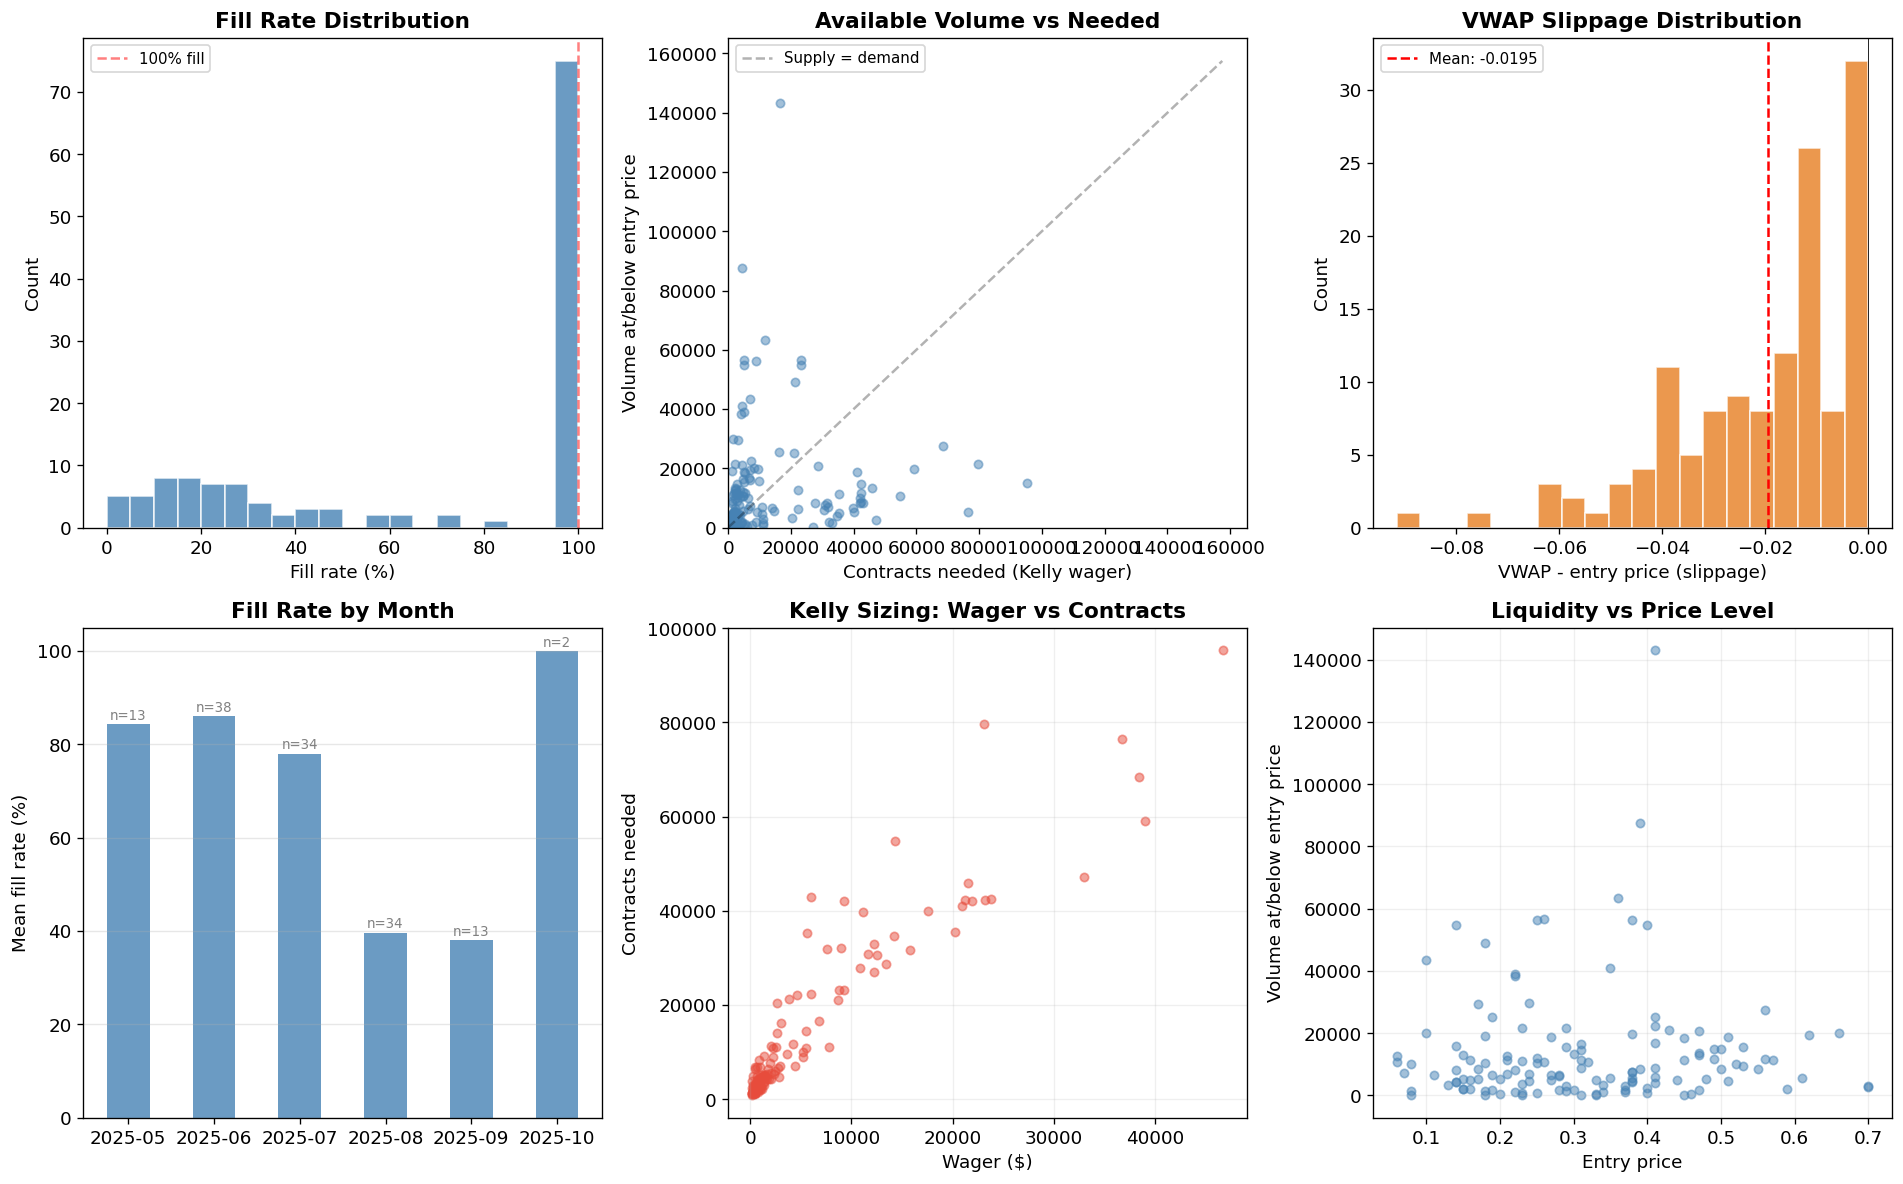

In [49]:
# --- Liquidity visualizations ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Fill rate distribution
ax = axes[0, 0]
ax.hist(fdf['fill_pct'] * 100, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(100, color='red', linestyle='--', alpha=0.5, label='100% fill')
ax.set_xlabel('Fill rate (%)')
ax.set_ylabel('Count')
ax.set_title('Fill Rate Distribution', fontweight='bold')
ax.legend(fontsize=9)

# Volume available vs volume needed
ax = axes[0, 1]
ax.scatter(fdf['n_needed'], fdf['volume_at_or_below'], alpha=0.5, s=25, color='steelblue')
max_val = max(fdf['n_needed'].max(), fdf['volume_at_or_below'].max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Supply = demand')
ax.set_xlabel('Contracts needed (Kelly wager)')
ax.set_ylabel('Volume at/below entry price')
ax.set_title('Available Volume vs Needed', fontweight='bold')
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.legend(fontsize=9)

# VWAP slippage distribution
ax = axes[0, 2]
valid = fdf[fdf['vwap'].notna()].copy()
if len(valid) > 0:
    slippage = valid['vwap'] - valid['entry_px']
    ax.hist(slippage, bins=20, color='#e67e22', alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.axvline(slippage.mean(), color='red', linestyle='--',
               label=f'Mean: {slippage.mean():.4f}')
    ax.set_xlabel('VWAP - entry price (slippage)')
    ax.set_ylabel('Count')
    ax.set_title('VWAP Slippage Distribution', fontweight='bold')
    ax.legend(fontsize=9)

# Fill rate over season
ax = axes[1, 0]
fdf_monthly = fdf.copy()
fdf_monthly['month'] = fdf_monthly['game_date'].dt.to_period('M')
monthly_fill = fdf_monthly.groupby('month').agg(
    mean_fill=('fill_pct', 'mean'),
    n_trades=('fill_pct', 'count'),
).reset_index()
monthly_fill['month_str'] = monthly_fill['month'].astype(str)
bars = ax.bar(monthly_fill['month_str'], monthly_fill['mean_fill'] * 100,
              color='steelblue', alpha=0.8, width=0.5)
for bar, n in zip(bars, monthly_fill['n_trades']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={int(n)}', ha='center', fontsize=8, color='gray')
ax.set_ylabel('Mean fill rate (%)')
ax.set_title('Fill Rate by Month', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Contracts needed vs wager size (Kelly scaling effect)
ax = axes[1, 1]
ax.scatter(fdf['wager'], fdf['n_needed'], alpha=0.5, s=25, color='#e74c3c')
ax.set_xlabel('Wager ($)')
ax.set_ylabel('Contracts needed')
ax.set_title('Kelly Sizing: Wager vs Contracts', fontweight='bold')
ax.grid(True, alpha=0.2)

# Volume at qualifying prices by entry price level
ax = axes[1, 2]
ax.scatter(fdf['entry_px'], fdf['volume_at_or_below'], alpha=0.5, s=25, color='steelblue')
ax.set_xlabel('Entry price')
ax.set_ylabel('Volume at/below entry price')
ax.set_title('Liquidity vs Price Level', fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [50]:
# --- Simulate realistic execution with liquidity constraints ---

def run_kelly_with_liquidity(entries, fraction, fill_data, bankroll_init):
    """Kelly sizing with liquidity constraints from actual trade data."""
    ents = sorted(entries, key=lambda x: x['entry_ts'])
    bankroll = bankroll_init
    trades_out = []
    fill_map = {r['game_id']: r for _, r in fill_data.iterrows()}

    for e in ents:
        kf = max((e['p_side'] - e['entry_px']) / (1 - e['entry_px']), 0)
        wager_ideal = kf * fraction * bankroll
        if wager_ideal < 0.01:
            continue

        n_ideal = wager_ideal / e['entry_px']
        fi = fill_map.get(e['game_id'])

        if fi is None or fi['volume_at_or_below'] == 0:
            continue  # no liquidity, skip

        # Cap at available volume
        n_actual = min(n_ideal, fi['volume_at_or_below'])
        actual_price = fi['vwap'] if (not np.isnan(fi['vwap']) and n_actual > 0) else e['entry_px']
        wager_actual = n_actual * actual_price

        fee = kalshi_taker_fee(n_actual, actual_price)
        pay = 1.0 if (e['side']=='YES' and e['home_win']==1) or (e['side']=='NO' and e['home_win']==0) else 0.0
        pnl = n_actual * pay - wager_actual - fee
        bankroll += pnl

        trades_out.append({
            **e, 'kelly_f': kf,
            'wager_ideal': wager_ideal, 'wager': wager_actual,
            'n_ideal': n_ideal, 'n_contracts': n_actual,
            'fill_pct': n_actual / n_ideal if n_ideal > 0 else 0,
            'entry_px_actual': actual_price,
            'fee': fee, 'pnl': pnl, 'won': int(pnl > 0), 'bankroll': bankroll,
        })
    return trades_out

# Ideal (no liquidity constraint) at $5k
tdf_ideal_5k = pd.DataFrame(trades_5k)
fb_ideal_5k = tdf_ideal_5k['bankroll'].iloc[-1]
ret_ideal_5k = (fb_ideal_5k - BANKROLL_REAL) / BANKROLL_REAL

# Liquidity-constrained at $5k
trades_real_5k = run_kelly_with_liquidity(entries, 0.5, fdf, BANKROLL_REAL)
tdf_real_5k = pd.DataFrame(trades_real_5k)

if len(tdf_real_5k) > 0:
    fb_real_5k = tdf_real_5k['bankroll'].iloc[-1]
    ret_real_5k = (fb_real_5k - BANKROLL_REAL) / BANKROLL_REAL

    ideal_hr = tdf_ideal_5k['won'].mean()
    real_hr = tdf_real_5k['won'].mean()
    real_fill = tdf_real_5k['fill_pct'].mean()
    real_slip = (tdf_real_5k['entry_px_actual'] - tdf_real_5k['entry_px']).mean()

    print('Half-Kelly: Ideal vs Liquidity-Constrained (${:.0f} bankroll)'.format(BANKROLL_REAL))
    print('{:25s} {:>12s} {:>12s}'.format('', 'Ideal', 'Realistic'))
    print('-' * 52)
    print('{:<25s} {:>12d} {:>12d}'.format('Trades', len(tdf_ideal_5k), len(tdf_real_5k)))
    print('{:<25s} {:>12s} {:>12s}'.format('Final bankroll', '${:.0f}'.format(fb_ideal_5k), '${:.0f}'.format(fb_real_5k)))
    print('{:<25s} {:>12s} {:>12s}'.format('Return', '{:.0%}'.format(ret_ideal_5k), '{:.0%}'.format(ret_real_5k)))
    print('{:<25s} {:>12s} {:>12s}'.format('Hit rate', '{:.1%}'.format(ideal_hr), '{:.1%}'.format(real_hr)))
    print('{:<25s} {:>12s} {:>12s}'.format('Mean fill %', '100.0%', '{:.1%}'.format(real_fill)))
    print('{:<25s} {:>12s} {:>12s}'.format('Mean slippage', '0.0000', '{:.4f}'.format(real_slip)))

    # Progression by quartile
    print('\n--- Wager & Fill Progression ---')
    tdf_r_copy = tdf_real_5k.copy()
    tdf_r_copy['quarter'] = pd.qcut(range(len(tdf_r_copy)), 4, labels=['Q1','Q2','Q3','Q4'])
    for q in ['Q1','Q2','Q3','Q4']:
        sub = tdf_r_copy[tdf_r_copy['quarter'] == q]
        print('  {}: {} trades, ideal wager ${:.0f}, contracts {:.0f}, fill {:.1%}'.format(
            q, len(sub), sub['wager_ideal'].mean(), sub['n_ideal'].mean(), sub['fill_pct'].mean()))
else:
    print('No trades survived liquidity filter.')

Half-Kelly: Ideal vs Liquidity-Constrained ($5000 bankroll)
                                 Ideal    Realistic
----------------------------------------------------
Trades                             134          134
Final bankroll                  $58246       $43250
Return                           1065%         765%
Hit rate                         40.3%        40.3%
Mean fill %                     100.0%        80.0%
Mean slippage                   0.0000      -0.0195

--- Wager & Fill Progression ---
  Q1: 34 trades, ideal wager $470, contracts 1876, fill 90.0%
  Q2: 33 trades, ideal wager $820, contracts 3005, fill 79.6%
  Q3: 33 trades, ideal wager $1294, contracts 3744, fill 83.5%
  Q4: 34 trades, ideal wager $6145, contracts 14988, fill 66.9%


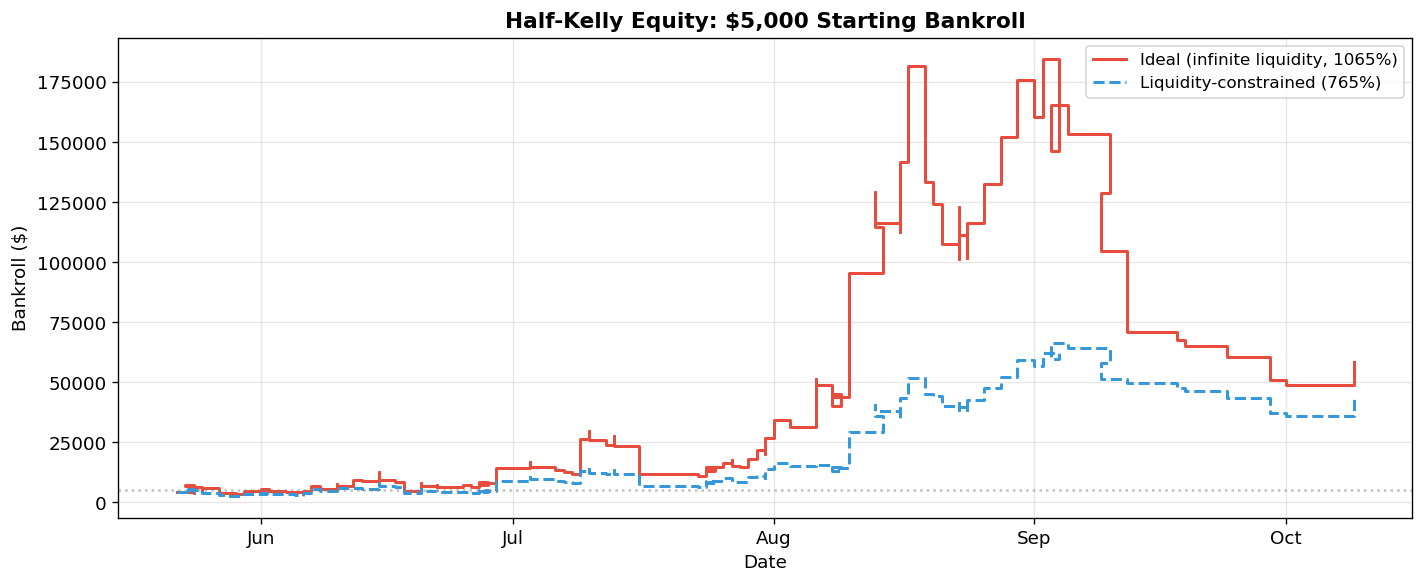

In [51]:
# --- Equity curve: ideal vs liquidity-constrained ($5,000 bankroll) ---
if len(tdf_real_5k) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))

    tdf_i5k_plot = tdf_ideal_5k.copy()
    tdf_i5k_plot['game_date'] = pd.to_datetime(tdf_i5k_plot['game_id'].map(game_dt_map))
    tdf_r5k_plot = tdf_real_5k.copy()
    tdf_r5k_plot['game_date'] = pd.to_datetime(tdf_r5k_plot['game_id'].map(game_dt_map))

    ax.step(tdf_i5k_plot['game_date'], tdf_i5k_plot['bankroll'], where='post',
            color='#e74c3c', linewidth=1.8,
            label='Ideal (infinite liquidity, {:.0%})'.format(ret_ideal_5k))
    ax.step(tdf_r5k_plot['game_date'], tdf_r5k_plot['bankroll'], where='post',
            color='#3498db', linewidth=1.8, linestyle='--',
            label='Liquidity-constrained ({:.0%})'.format(ret_real_5k))
    ax.axhline(BANKROLL_REAL, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Date')
    ax.set_ylabel('Bankroll ($)')
    ax.set_title('Half-Kelly Equity: $5,000 Starting Bankroll', fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

    plt.tight_layout()
    plt.show()

In [52]:
# --- Liquidity summary ($5,000 starting bankroll) ---
print('=== Liquidity Analysis Summary ($5,000 bankroll) ===')
if len(tdf_real_5k) > 0:
    print('\nOf {} planned trades:'.format(len(tdf_real_5k)))
    full = (tdf_real_5k['fill_pct'] >= 1.0).sum()
    partial = ((tdf_real_5k['fill_pct'] > 0) & (tdf_real_5k['fill_pct'] < 1)).sum()
    zero = (tdf_real_5k['fill_pct'] == 0).sum()
    print('  {} ({:.1%}) fully fillable'.format(full, full / len(tdf_real_5k)))
    print('  {} partially fillable'.format(partial))
    print('  {} unfillable'.format(zero))

    print('\nWager statistics:')
    print('  Mean ideal wager: ${:.0f}'.format(tdf_real_5k['wager_ideal'].mean()))
    print('  Max ideal wager:  ${:.0f}'.format(tdf_real_5k['wager_ideal'].max()))
    print('  Mean contracts needed: {:.0f}'.format(tdf_real_5k['n_ideal'].mean()))
    print('  Max contracts needed:  {:.0f}'.format(tdf_real_5k['n_ideal'].max()))

    print('\nVolume context (from fill analysis):')
    print('  Median volume at/below entry: {:.0f} contracts'.format(fdf['volume_at_or_below'].median()))
    ratio = fdf['volume_at_or_below'] / fdf['n_needed'].clip(lower=0.01)
    # Recompute at 5k scale
    ratio_5k = fdf['volume_at_or_below'] / (fdf['n_needed'] * BANKROLL_REAL / BANKROLL_INIT)
    print('  Median supply/demand ratio ($100 scale): {:.1f}x'.format(ratio.median()))
    print('  Median supply/demand ratio ($5,000 scale): {:.1f}x'.format(ratio_5k.median()))

    print('\nExecution impact:')
    print('  Ideal return:     {:.0%}'.format(ret_ideal_5k))
    print('  Realistic return: {:.0%}'.format(ret_real_5k))
    if ret_ideal_5k > 0:
        haircut = (ret_ideal_5k - ret_real_5k) / ret_ideal_5k * 100
        print('  Return haircut:   {:.1f}%'.format(haircut))

    print('\nProgression by trade quartile:')
    tdf_r_copy = tdf_real_5k.copy()
    tdf_r_copy['quarter'] = pd.qcut(range(len(tdf_r_copy)), 4, labels=['Q1','Q2','Q3','Q4'])
    for q in ['Q1','Q2','Q3','Q4']:
        sub = tdf_r_copy[tdf_r_copy['quarter'] == q]
        print('  {}: mean wager ${:.0f}, mean contracts {:.0f}, fill {:.1%}'.format(
            q, sub['wager_ideal'].mean(), sub['n_ideal'].mean(), sub['fill_pct'].mean()))

=== Liquidity Analysis Summary ($5,000 bankroll) ===

Of 134 planned trades:
  84 (62.7%) fully fillable
  50 partially fillable
  0 unfillable

Wager statistics:
  Mean ideal wager: $2199
  Max ideal wager:  $16235
  Mean contracts needed: 5941
  Max contracts needed:  33398

Volume context (from fill analysis):
  Median volume at/below entry: 8364 contracts
  Median supply/demand ratio ($100 scale): 1.3x
  Median supply/demand ratio ($5,000 scale): 0.0x

Execution impact:
  Ideal return:     1065%
  Realistic return: 765%
  Return haircut:   28.2%

Progression by trade quartile:
  Q1: mean wager $470, mean contracts 1876, fill 90.0%
  Q2: mean wager $820, mean contracts 3005, fill 79.6%
  Q3: mean wager $1294, mean contracts 3744, fill 83.5%
  Q4: mean wager $6145, mean contracts 14988, fill 66.9%


---
## 5. Limit Order Fill Analysis

The sweep analysis above asks "how much volume traded at or below our price?"
But a **resting limit order** at our max entry price only fills when someone
**trades through that exact price** — i.e., a taker hits our resting bid.

A trade at $0.28 when our limit is at $0.31 doesn't fill us — it means
someone else traded at $0.28 with a different counterparty.

Our limit order fills when:
- **YES side**: someone sells YES at or below our limit price (a YES ask <= our price gets matched)
- **NO side**: someone sells NO at or below our limit price

In the trades data, a trade at our price or crossing through it represents
a transaction that *could* have filled our resting order. We count volume
at exactly our entry price or at prices that would cross through it
(i.e., trades where the taker is on the opposite side at our price level).

In [53]:
# --- Limit order fill analysis ---
# For each of our trades, count how many contracts traded at EXACTLY our
# entry price during the window. These are the trades that would have
# filled a resting limit order.
#
# On Kalshi, if we post a YES limit buy at 0.31, it fills when:
#   - A YES sell (taker_side='no' or equivalently someone selling YES) at <= 0.31
# In the trades data, a trade with yes_price=0.31 and taker_side in either direction
# means a transaction occurred at that price level.
#
# Conservative approach: count volume at exactly our entry price.
# A limit order at 0.31 fills against trades AT 0.31.

limit_analysis = []
for _, trade in tdf_5k.iterrows():
    gid = trade['game_id']
    side = trade['side']
    entry_px = trade['entry_px']
    n_needed = trade['n_contracts']

    game_trades = wt[wt['game_id'] == gid].copy()
    if game_trades.empty:
        limit_analysis.append({
            'game_id': gid, 'side': side, 'entry_px': entry_px,
            'n_needed': n_needed, 'wager': trade['wager'],
            'vol_at_price': 0, 'vol_near_price': 0,
            'total_volume': 0, 'limit_fill_pct': 0,
            'near_fill_pct': 0,
        })
        continue

    if side == 'YES':
        game_trades['our_price'] = game_trades['yes_price']
    else:
        game_trades['our_price'] = game_trades['no_price']

    total_vol = game_trades['count'].sum()

    # Strict: volume at exactly our price
    at_price = game_trades[game_trades['our_price'] == entry_px]
    vol_at_price = at_price['count'].sum()

    # Relaxed: volume within 1 cent of our price (our price +/- 0.01)
    near_price = game_trades[(game_trades['our_price'] >= entry_px - 0.01) &
                             (game_trades['our_price'] <= entry_px)]
    vol_near_price = near_price['count'].sum()

    limit_analysis.append({
        'game_id': gid, 'side': side, 'entry_px': entry_px,
        'n_needed': n_needed, 'wager': trade['wager'],
        'vol_at_price': vol_at_price, 'vol_near_price': vol_near_price,
        'total_volume': total_vol,
        'limit_fill_pct': min(vol_at_price / n_needed, 1.0) if n_needed > 0 else 0,
        'near_fill_pct': min(vol_near_price / n_needed, 1.0) if n_needed > 0 else 0,
    })

ldf = pd.DataFrame(limit_analysis)
ldf['game_date'] = pd.to_datetime(ldf['game_id'].map(game_dt_map))

print('Limit Order Fill Analysis ($5,000 bankroll)')
print(f'\n--- Volume at Exact Entry Price ---')
print(f'Mean volume at price:  {ldf["vol_at_price"].mean():.0f} contracts')
print(f'Mean contracts needed: {ldf["n_needed"].mean():.0f}')
print(f'Mean fill %:           {ldf["limit_fill_pct"].mean():.1%}')
print(f'Median fill %:         {ldf["limit_fill_pct"].median():.1%}')
print(f'Fully fillable:        {(ldf["limit_fill_pct"] >= 1.0).mean():.1%}')
print(f'Zero volume at price:  {(ldf["vol_at_price"] == 0).mean():.1%}')
print(f'\n--- Volume Within 1 Cent of Entry Price ---')
print(f'Mean volume near price: {ldf["vol_near_price"].mean():.0f} contracts')
print(f'Mean fill %:            {ldf["near_fill_pct"].mean():.1%}')
print(f'Median fill %:          {ldf["near_fill_pct"].median():.1%}')
print(f'Fully fillable:         {(ldf["near_fill_pct"] >= 1.0).mean():.1%}')

Limit Order Fill Analysis ($5,000 bankroll)

--- Volume at Exact Entry Price ---
Mean volume at price:  2577 contracts
Mean contracts needed: 14161
Mean fill %:           25.5%
Median fill %:         4.5%
Fully fillable:        17.2%
Zero volume at price:  37.3%

--- Volume Within 1 Cent of Entry Price ---
Mean volume near price: 6050 contracts
Mean fill %:            48.0%
Median fill %:          32.1%
Fully fillable:         32.8%


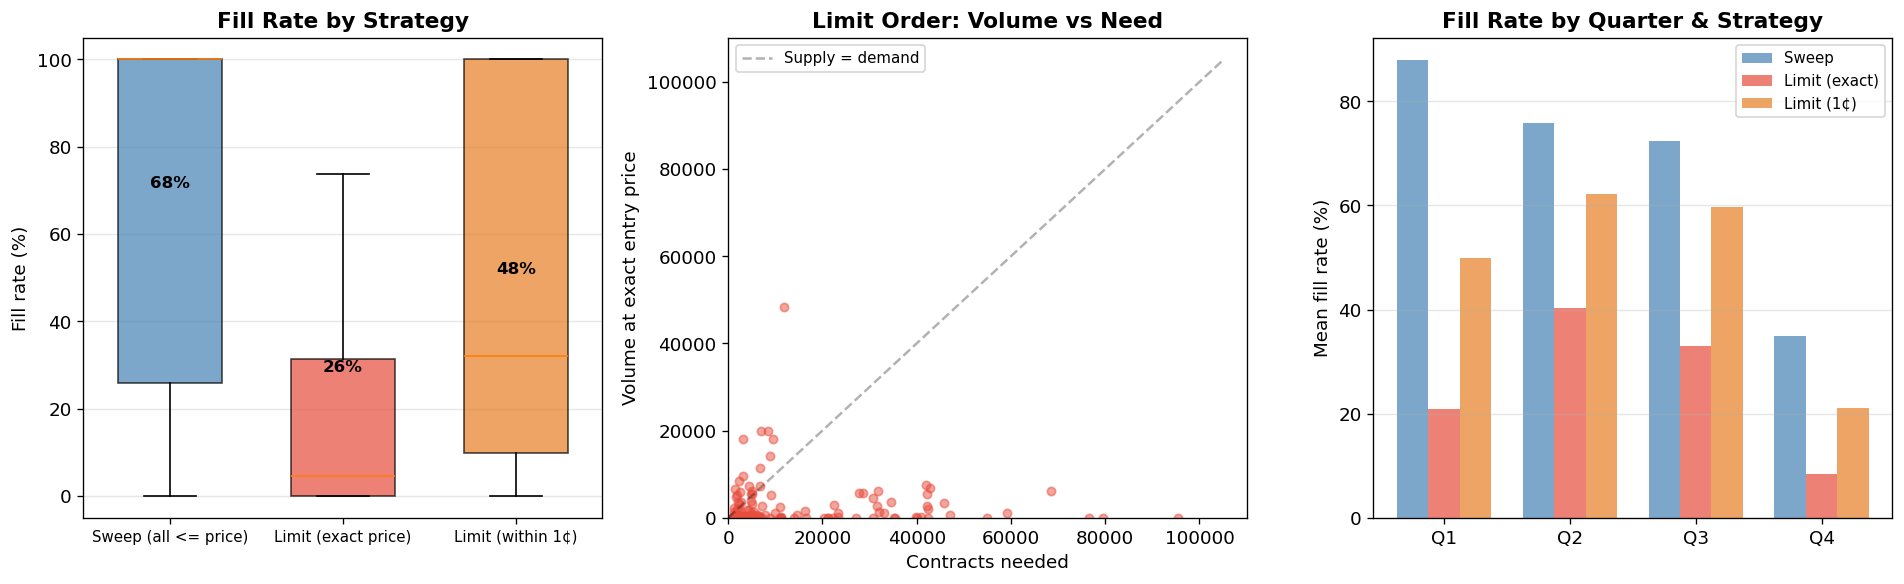

In [54]:
# --- Compare fill strategies ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fill rate comparison: sweep vs limit at price vs limit near price
ax = axes[0]
strategies = {
    'Sweep (all <= price)': fdf['fill_pct'],
    'Limit (exact price)': ldf['limit_fill_pct'],
    'Limit (within 1\u00a2)': ldf['near_fill_pct'],
}
positions = range(len(strategies))
colors = ['steelblue', '#e74c3c', '#e67e22']
for pos, ((label, vals), color) in enumerate(zip(strategies.items(), colors)):
    bp = ax.boxplot(vals * 100, positions=[pos], widths=0.6,
                    patch_artist=True, showfliers=False)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    ax.text(pos, vals.mean() * 100 + 3, '{:.0f}%'.format(vals.mean() * 100),
            ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(list(positions))
ax.set_xticklabels(list(strategies.keys()), fontsize=9)
ax.set_ylabel('Fill rate (%)')
ax.set_title('Fill Rate by Strategy', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Volume at exact price vs needed (scatter)
ax = axes[1]
ax.scatter(ldf['n_needed'], ldf['vol_at_price'], alpha=0.5, s=25, color='#e74c3c')
max_val = max(ldf['n_needed'].max(), ldf['vol_at_price'].max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Supply = demand')
ax.set_xlabel('Contracts needed')
ax.set_ylabel('Volume at exact entry price')
ax.set_title('Limit Order: Volume vs Need', fontweight='bold')
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.legend(fontsize=9)

# Fill rate over season (limit vs sweep)
ax = axes[2]
ldf_m = ldf.copy()
ldf_m['quarter'] = pd.qcut(range(len(ldf_m)), 4, labels=['Q1','Q2','Q3','Q4'])
fdf_m = fdf.copy()
fdf_m['quarter'] = pd.qcut(range(len(fdf_m)), 4, labels=['Q1','Q2','Q3','Q4'])

q_labels = ['Q1','Q2','Q3','Q4']
sweep_fills = [fdf_m[fdf_m['quarter']==q]['fill_pct'].mean() * 100 for q in q_labels]
limit_fills = [ldf_m[ldf_m['quarter']==q]['limit_fill_pct'].mean() * 100 for q in q_labels]
near_fills = [ldf_m[ldf_m['quarter']==q]['near_fill_pct'].mean() * 100 for q in q_labels]

x = np.arange(len(q_labels))
w = 0.25
ax.bar(x - w, sweep_fills, w, label='Sweep', color='steelblue', alpha=0.7)
ax.bar(x, limit_fills, w, label='Limit (exact)', color='#e74c3c', alpha=0.7)
ax.bar(x + w, near_fills, w, label='Limit (1\u00a2)', color='#e67e22', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(q_labels)
ax.set_ylabel('Mean fill rate (%)')
ax.set_title('Fill Rate by Quarter & Strategy', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
# --- Limit order execution simulation ---
# Run half-Kelly at $5k but only fill contracts at exactly our entry price

def run_kelly_limit_order(entries, fraction, limit_fill_data, bankroll_init):
    """Kelly sizing where fills are capped at volume at exact entry price."""
    ents = sorted(entries, key=lambda x: x['entry_ts'])
    bankroll = bankroll_init
    trades_out = []
    fill_map = {r['game_id']: r for _, r in limit_fill_data.iterrows()}

    for e in ents:
        kf = max((e['p_side'] - e['entry_px']) / (1 - e['entry_px']), 0)
        wager_ideal = kf * fraction * bankroll
        if wager_ideal < 0.01:
            continue

        n_ideal = wager_ideal / e['entry_px']
        fi = fill_map.get(e['game_id'])

        if fi is None or fi['vol_at_price'] == 0:
            continue

        n_actual = min(n_ideal, fi['vol_at_price'])
        wager_actual = n_actual * e['entry_px']  # limit order fills at our price

        fee = kalshi_taker_fee(n_actual, e['entry_px'])
        pay = 1.0 if (e['side']=='YES' and e['home_win']==1) or (e['side']=='NO' and e['home_win']==0) else 0.0
        pnl = n_actual * pay - wager_actual - fee
        bankroll += pnl

        trades_out.append({
            **e, 'kelly_f': kf,
            'wager_ideal': wager_ideal, 'wager': wager_actual,
            'n_ideal': n_ideal, 'n_contracts': n_actual,
            'fill_pct': n_actual / n_ideal if n_ideal > 0 else 0,
            'fee': fee, 'pnl': pnl, 'won': int(pnl > 0), 'bankroll': bankroll,
        })
    return trades_out

trades_limit_5k = run_kelly_limit_order(entries, 0.5, ldf, BANKROLL_REAL)
tdf_limit_5k = pd.DataFrame(trades_limit_5k)

if len(tdf_limit_5k) > 0:
    fb_limit = tdf_limit_5k['bankroll'].iloc[-1]
    ret_limit = (fb_limit - BANKROLL_REAL) / BANKROLL_REAL
    limit_fill_mean = tdf_limit_5k['fill_pct'].mean()

    print('Execution Strategy Comparison ($5,000 bankroll)')
    print('{:30s} {:>10s} {:>10s} {:>10s}'.format('', 'Ideal', 'Sweep', 'Limit'))
    print('-' * 63)
    print('{:<30s} {:>10d} {:>10d} {:>10d}'.format('Trades', len(tdf_ideal_5k), len(tdf_real_5k), len(tdf_limit_5k)))
    print('{:<30s} {:>10s} {:>10s} {:>10s}'.format('Final bankroll',
        '${:.0f}'.format(fb_ideal_5k), '${:.0f}'.format(fb_real_5k), '${:.0f}'.format(fb_limit)))
    print('{:<30s} {:>10s} {:>10s} {:>10s}'.format('Return',
        '{:.0%}'.format(ret_ideal_5k), '{:.0%}'.format(ret_real_5k), '{:.0%}'.format(ret_limit)))
    print('{:<30s} {:>10s} {:>10s} {:>10s}'.format('Mean fill %',
        '100.0%', '{:.1%}'.format(tdf_real_5k['fill_pct'].mean()), '{:.1%}'.format(limit_fill_mean)))
    print('{:<30s} {:>10s} {:>10s} {:>10s}'.format('Fills at entry price',
        'No', 'No (VWAP)', 'Yes'))
else:
    print('No trades filled with limit orders.')

Execution Strategy Comparison ($5,000 bankroll)
                                    Ideal      Sweep      Limit
---------------------------------------------------------------
Trades                                134        134         84
Final bankroll                     $58246     $43250     $35001
Return                              1065%       765%       600%
Mean fill %                        100.0%      80.0%      49.2%
Fills at entry price                   No  No (VWAP)        Yes


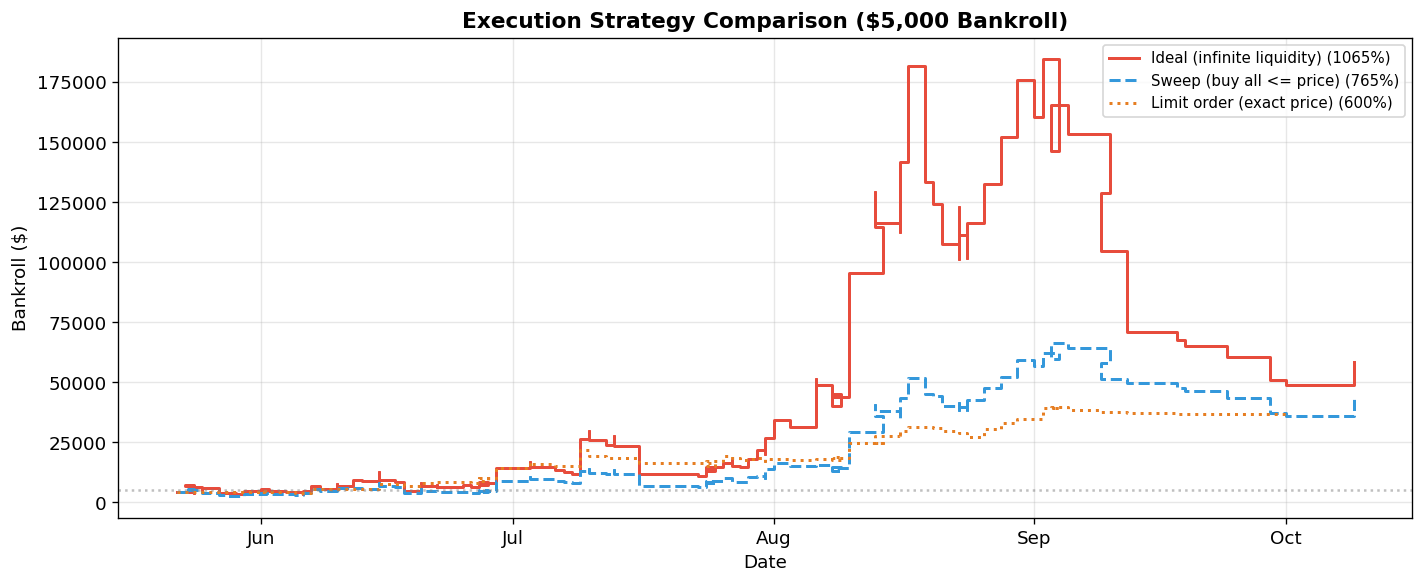

In [56]:
# --- Equity curves: all three strategies ---
fig, ax = plt.subplots(figsize=(12, 5))

curves = [
    ('Ideal (infinite liquidity)', tdf_ideal_5k, '#e74c3c', '-', ret_ideal_5k),
    ('Sweep (buy all <= price)', tdf_real_5k, '#3498db', '--', ret_real_5k),
]
if len(tdf_limit_5k) > 0:
    curves.append(('Limit order (exact price)', tdf_limit_5k, '#e67e22', ':', ret_limit))

for label, df, color, ls, ret in curves:
    df_plot = df.copy()
    df_plot['game_date'] = pd.to_datetime(df_plot['game_id'].map(game_dt_map))
    ax.step(df_plot['game_date'], df_plot['bankroll'], where='post',
            color=color, linewidth=1.8, linestyle=ls,
            label='{} ({:.0%})'.format(label, ret))

ax.axhline(BANKROLL_REAL, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Bankroll ($)')
ax.set_title('Execution Strategy Comparison ($5,000 Bankroll)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

plt.tight_layout()
plt.show()

---
## 6. Optimal Bankroll Sizing

More capital means more dollars wagered, but also more contracts needed.
At some point the bankroll outgrows available liquidity and returns degrade.

We sweep through starting bankrolls from $100 to $10,000 and run both
the ideal (infinite liquidity) and realistic (sweep all available <= entry price)
simulations to find where the crossover happens.

In [57]:
# --- Bankroll sweep: ideal vs realistic execution ---
BANKROLL_LEVELS = [100, 500, 1000, 2500, 5000, 7500, 10000]

def run_kelly_ideal_br(entries, fraction, bankroll_init):
    ents = sorted(entries, key=lambda x: x['entry_ts'])
    bankroll = bankroll_init
    trades_out = []
    for e in ents:
        kf = max((e['p_side'] - e['entry_px']) / (1 - e['entry_px']), 0)
        wager = kf * fraction * bankroll
        if wager < 0.01:
            continue
        n = wager / e['entry_px']
        fee = kalshi_taker_fee(n, e['entry_px'])
        pay = 1.0 if (e['side']=='YES' and e['home_win']==1) or (e['side']=='NO' and e['home_win']==0) else 0.0
        pnl = n * pay - wager - fee
        bankroll += pnl
        trades_out.append({**e, 'kelly_f': kf, 'wager': wager, 'n_contracts': n,
                           'fee': fee, 'pnl': pnl, 'won': int(pnl > 0), 'bankroll': bankroll})
    return trades_out

def run_kelly_sweep_br(entries, fraction, bankroll_init, trade_data):
    """Kelly with sweep execution: buy all available contracts <= entry price."""
    ents = sorted(entries, key=lambda x: x['entry_ts'])
    bankroll = bankroll_init
    trades_out = []

    for e in ents:
        kf = max((e['p_side'] - e['entry_px']) / (1 - e['entry_px']), 0)
        wager_ideal = kf * fraction * bankroll
        if wager_ideal < 0.01:
            continue

        n_ideal = wager_ideal / e['entry_px']
        gid = e['game_id']

        # Get trades for this game in the window
        game_trades = trade_data[trade_data['game_id'] == gid].copy()
        if game_trades.empty:
            continue

        if e['side'] == 'YES':
            game_trades['our_price'] = game_trades['yes_price']
        else:
            game_trades['our_price'] = game_trades['no_price']

        qualifying = game_trades[game_trades['our_price'] <= e['entry_px']].sort_values('our_price')
        if qualifying.empty:
            continue

        # Sweep from cheapest up
        filled = 0
        cost = 0
        for _, t in qualifying.iterrows():
            can_take = min(t['count'], n_ideal - filled)
            filled += can_take
            cost += can_take * t['our_price']
            if filled >= n_ideal:
                break

        if filled == 0:
            continue

        vwap = cost / filled
        wager_actual = cost
        n_actual = filled

        fee = kalshi_taker_fee(n_actual, vwap)
        pay = 1.0 if (e['side']=='YES' and e['home_win']==1) or (e['side']=='NO' and e['home_win']==0) else 0.0
        pnl = n_actual * pay - wager_actual - fee
        bankroll += pnl

        trades_out.append({
            **e, 'kelly_f': kf,
            'wager_ideal': wager_ideal, 'wager': wager_actual,
            'n_ideal': n_ideal, 'n_contracts': n_actual,
            'fill_pct': n_actual / n_ideal if n_ideal > 0 else 0,
            'fee': fee, 'pnl': pnl, 'won': int(pnl > 0), 'bankroll': bankroll,
        })
    return trades_out

results = []
for br in BANKROLL_LEVELS:
    # Ideal
    t_ideal = run_kelly_ideal_br(entries, 0.5, br)
    df_ideal = pd.DataFrame(t_ideal)
    fb_ideal = df_ideal['bankroll'].iloc[-1] if len(df_ideal) > 0 else br
    pnl_ideal = fb_ideal - br
    ret_ideal = pnl_ideal / br

    # Realistic sweep
    t_real = run_kelly_sweep_br(entries, 0.5, br, wt)
    df_real = pd.DataFrame(t_real)
    fb_real = df_real['bankroll'].iloc[-1] if len(df_real) > 0 else br
    pnl_real = fb_real - br
    ret_real = pnl_real / br
    mean_fill = df_real['fill_pct'].mean() if len(df_real) > 0 else 0

    results.append({
        'bankroll': br,
        'ideal_final': fb_ideal, 'ideal_pnl': pnl_ideal, 'ideal_return': ret_ideal,
        'real_final': fb_real, 'real_pnl': pnl_real, 'real_return': ret_real,
        'n_trades_ideal': len(df_ideal), 'n_trades_real': len(df_real),
        'mean_fill': mean_fill,
    })

rdf = pd.DataFrame(results)

print('Bankroll Sweep: Ideal vs Sweep Execution')
print('{:>10s} {:>12s} {:>12s} {:>10s} {:>12s} {:>12s} {:>10s} {:>8s}'.format(
    'Bankroll', 'Ideal Final', 'Ideal PnL', 'Ideal %', 'Real Final', 'Real PnL', 'Real %', 'Fill %'))
print('-' * 92)
for _, r in rdf.iterrows():
    print('{:>10s} {:>12s} {:>12s} {:>10s} {:>12s} {:>12s} {:>10s} {:>8s}'.format(
        '${:,.0f}'.format(r['bankroll']),
        '${:,.0f}'.format(r['ideal_final']),
        '${:,.0f}'.format(r['ideal_pnl']),
        '{:.0%}'.format(r['ideal_return']),
        '${:,.0f}'.format(r['real_final']),
        '${:,.0f}'.format(r['real_pnl']),
        '{:.0%}'.format(r['real_return']),
        '{:.0%}'.format(r['mean_fill']),
    ))

Bankroll Sweep: Ideal vs Sweep Execution
  Bankroll  Ideal Final    Ideal PnL    Ideal %   Real Final     Real PnL     Real %   Fill %
--------------------------------------------------------------------------------------------
      $100       $1,162       $1,062      1062%       $2,647       $2,547      2547%      98%
      $500       $5,822       $5,322      1064%       $9,940       $9,440      1888%      95%
    $1,000      $11,647      $10,647      1065%      $15,391      $14,391      1439%      92%
    $2,500      $29,121      $26,621      1065%      $34,024      $31,524      1261%      84%
    $5,000      $58,246      $53,246      1065%      $45,276      $40,276       806%      79%
    $7,500      $87,370      $79,870      1065%      $57,115      $49,615       662%      76%
   $10,000     $116,494     $106,494      1065%      $67,735      $57,735       577%      71%


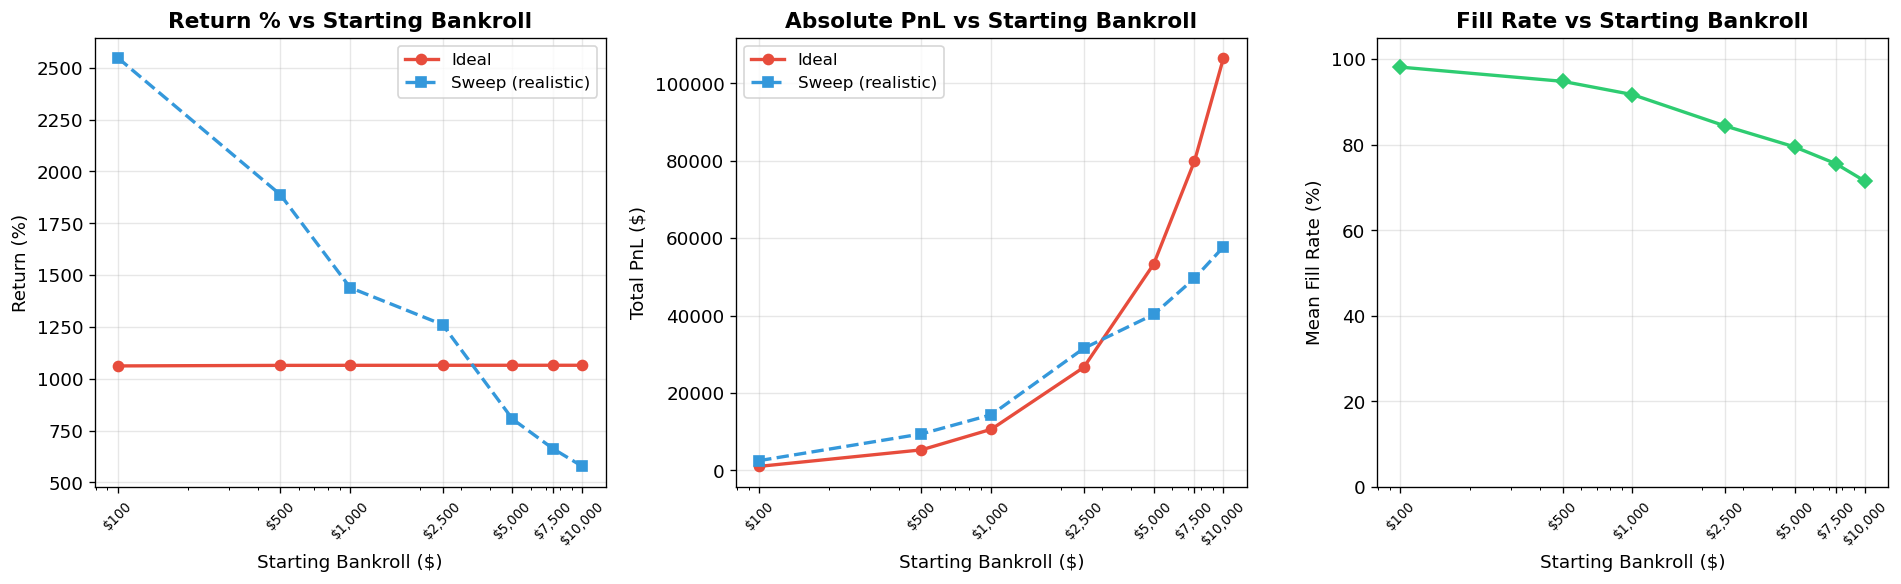

In [58]:
# --- Visualize bankroll sweep ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bankrolls = rdf['bankroll'].values

# Return %
ax = axes[0]
ax.plot(bankrolls, rdf['ideal_return'] * 100, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='Ideal')
ax.plot(bankrolls, rdf['real_return'] * 100, 's--', color='#3498db', linewidth=2, markersize=6, label='Sweep (realistic)')
ax.set_xlabel('Starting Bankroll ($)')
ax.set_ylabel('Return (%)')
ax.set_title('Return % vs Starting Bankroll', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_xticks(bankrolls)
ax.set_xticklabels(['${:,.0f}'.format(b) for b in bankrolls], rotation=45, fontsize=8)

# Absolute PnL
ax = axes[1]
ax.plot(bankrolls, rdf['ideal_pnl'], 'o-', color='#e74c3c', linewidth=2, markersize=6, label='Ideal')
ax.plot(bankrolls, rdf['real_pnl'], 's--', color='#3498db', linewidth=2, markersize=6, label='Sweep (realistic)')
ax.set_xlabel('Starting Bankroll ($)')
ax.set_ylabel('Total PnL ($)')
ax.set_title('Absolute PnL vs Starting Bankroll', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_xticks(bankrolls)
ax.set_xticklabels(['${:,.0f}'.format(b) for b in bankrolls], rotation=45, fontsize=8)

# Mean fill rate
ax = axes[2]
ax.plot(bankrolls, rdf['mean_fill'] * 100, 'D-', color='#2ecc71', linewidth=2, markersize=6)
ax.set_xlabel('Starting Bankroll ($)')
ax.set_ylabel('Mean Fill Rate (%)')
ax.set_title('Fill Rate vs Starting Bankroll', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_xticks(bankrolls)
ax.set_xticklabels(['${:,.0f}'.format(b) for b in bankrolls], rotation=45, fontsize=8)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

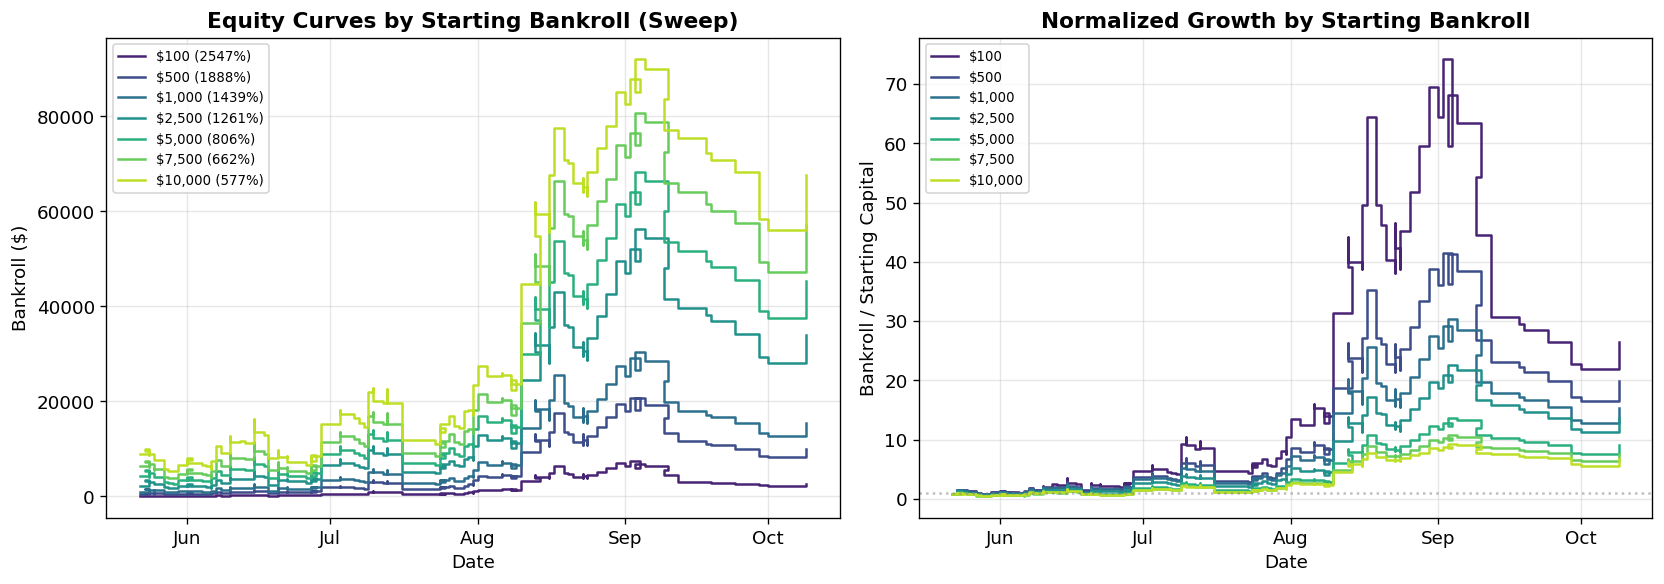

In [59]:
# --- Equity curves for all bankroll levels (sweep execution) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(BANKROLL_LEVELS)))

# Absolute bankroll
ax = axes[0]
for br, color in zip(BANKROLL_LEVELS, colors):
    t = run_kelly_sweep_br(entries, 0.5, br, wt)
    if not t:
        continue
    df = pd.DataFrame(t)
    df['game_date'] = pd.to_datetime(df['game_id'].map(game_dt_map))
    ret = (df['bankroll'].iloc[-1] / br - 1)
    ax.step(df['game_date'], df['bankroll'], where='post',
            color=color, linewidth=1.5,
            label='${:,.0f} ({:.0%})'.format(br, ret))

ax.set_xlabel('Date')
ax.set_ylabel('Bankroll ($)')
ax.set_title('Equity Curves by Starting Bankroll (Sweep)', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

# Normalized (bankroll / starting bankroll)
ax = axes[1]
for br, color in zip(BANKROLL_LEVELS, colors):
    t = run_kelly_sweep_br(entries, 0.5, br, wt)
    if not t:
        continue
    df = pd.DataFrame(t)
    df['game_date'] = pd.to_datetime(df['game_id'].map(game_dt_map))
    ax.step(df['game_date'], df['bankroll'] / br, where='post',
            color=color, linewidth=1.5,
            label='${:,.0f}'.format(br))

ax.axhline(1, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Bankroll / Starting Capital')
ax.set_title('Normalized Growth by Starting Bankroll', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

plt.tight_layout()
plt.show()